# Tufa Labs ARC3 submission

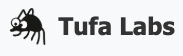

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Qwen3.8 / Kaggle input configuration
DATASET_SOURCES: list[str] = [
    "samrishb/taaf-kaggle-source-grafts",
    "driessmit1/arc3-vllm-h100-wheelhouse-v3",
]
KERNEL_SOURCES: list[str] = []

# New private Kaggle Model (Version 1).
QWEN_MODEL_OWNER = "foysalemonshanto"
QWEN_MODEL_SLUG = "qwen3-8-27b-fp8-repacked-v1"
QWEN_MODEL_REF = f"{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}"
QWEN_MODEL_VARIATION = "hf-fp8"
QWEN_MODEL_VERSION = "1"
QWEN_SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"
QWEN_MODEL_PATH = Path(
    f"/kaggle/input/models/{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}/"
    f"pytorch/{QWEN_MODEL_VARIATION}/{QWEN_MODEL_VERSION}"
)

DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
WORKING_DIR = Path(os.getenv("TAAF_KAGGLE_WORKING_DIR", "/kaggle/working")).resolve()
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"
SOFT_DEADLINE_BUFFER_S = 600.0
WORKING_DIR.mkdir(parents=True, exist_ok=True)

# Keep the whole run offline. vLLM/Transformers must use the mounted files only.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


def _split_ref(ref: str) -> tuple[str, str]:
    owner, slug = ref.split("/", 1)
    return owner, slug


def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = _split_ref(ref)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = _split_ref(ref)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((candidate for candidate in candidates if candidate.exists()), None)


def _find_taaf_bundle() -> Path:
    explicit = os.getenv("TAAF_KAGGLE_BUNDLE_DIR", "").strip()
    if explicit:
        path = Path(explicit)
        if (path / DATASET_BUNDLE_MARKER).is_file():
            return path

    # Pick the attached bundle by what it CONTAINS: the one carrying
    # src/taaf-grafts, so the behavioural grafts import instead of falling back
    # to stock. This is the v14 regression's root cause, fixed in v15/v16.
    markers = sorted(Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER))
    if not markers:
        raise RuntimeError("Could not find TAAF Kaggle source bundle dataset.")
    with_grafts = [m.parent for m in markers if (m.parent / "src" / "taaf-grafts").is_dir()]
    if with_grafts:
        if len(markers) > 1:
            print(
                f"taaf.kaggle: {len(markers)} source bundles attached; chose the one "
                "carrying src/taaf-grafts"
            )
        return with_grafts[0]
    print(
        "taaf.kaggle: *** WARNING *** no attached bundle carries src/taaf-grafts, so "
        "every behavioural graft falls back to stock. Bundles seen: "
        + ", ".join(str(m.parent) for m in markers)
    )
    return markers[0].parent

def _load_setup_env() -> dict[str, str]:
    if not SETUP_ENV_PATH.is_file():
        return {}
    data = json.loads(SETUP_ENV_PATH.read_text(encoding="utf-8"))
    if not isinstance(data, dict):
        raise RuntimeError(f"{SETUP_ENV_PATH} must contain a JSON object.")
    return {str(key): str(value) for key, value in data.items()}


def _write_setup_env_updates(updates: dict[str, str]) -> None:
    data = _load_setup_env()
    data.update(updates)
    SETUP_ENV_PATH.write_text(
        json.dumps(data, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )


BUNDLE_DIR = _find_taaf_bundle()
print(f"TAAF source bundle: {BUNDLE_DIR}")

# Verify the Qwen3.8 Kaggle Model before any expensive setup work starts.
if not QWEN_MODEL_PATH.is_dir():
    raise FileNotFoundError(
        "Qwen3.8 Kaggle Model is not attached.\n"
        f"Expected path:\n{QWEN_MODEL_PATH}\n\n"
        "Attach: Qwen3.8 27B FP8 Repacked → PyTorch → hf-fp8 → Version 1"
    )

_required_qwen_files = [
    "config.json",
    "model.safetensors.index.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "outside.safetensors",
    "mtp.safetensors",
    "chat_template.jinja",
]
_missing_qwen_files = [
    name for name in _required_qwen_files if not (QWEN_MODEL_PATH / name).is_file()
]
if _missing_qwen_files:
    raise FileNotFoundError(
        "Qwen3.8 mount is incomplete; missing: " + ", ".join(_missing_qwen_files)
    )

_qwen_layer_shards = sorted(QWEN_MODEL_PATH.glob("model-layers-*.safetensors"))
_qwen_safetensors = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
if len(_qwen_layer_shards) != 16 or len(_qwen_safetensors) != 18:
    raise RuntimeError(
        "Unexpected Qwen3.8 checkpoint layout: "
        f"{len(_qwen_layer_shards)} layer shards, "
        f"{len(_qwen_safetensors)} safetensors files."
    )

# Tell setup commands and solver code where Kaggle mounted every attached input.
kaggle_input_paths: dict[str, str] = {}
for index, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if index == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])

for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# The bundled setup resolver asks for owner/slug. Give it a model ref that maps
# directly to the full Kaggle Model version directory.
kaggle_input_paths[QWEN_MODEL_REF] = str(QWEN_MODEL_PATH)

setup_env = {
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    "TAAF_QWEN_MODEL_REF": QWEN_MODEL_REF,
    "TAAF_QWEN_MODEL_PATH": str(QWEN_MODEL_PATH),
    "TAAF_QWEN_SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    "HF_HUB_OFFLINE": "1",
    "TRANSFORMERS_OFFLINE": "1",
}
os.environ.update(setup_env)
_write_setup_env_updates(setup_env)

print("\n✅ Qwen3.8 input configuration ready")
print(f"Model ref:       {QWEN_MODEL_REF}")
print(f"Physical path:   {QWEN_MODEL_PATH}")
print(f"Served model:    {QWEN_SERVED_MODEL_NAME}")
print(f"Safetensors:     {len(_qwen_safetensors)}")
print(f"Layer shards:    {len(_qwen_layer_shards)}")
print(f"TAAF input map:  {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")


## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
import re


def _source_path_entries(bundle_dir: Path) -> list[Path]:
    src_root = bundle_dir / "src"
    if not src_root.is_dir():
        return []

    entries: list[Path] = []
    for repo in sorted(src_root.iterdir(), reverse=True):
        if not repo.is_dir():
            continue
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


def _command_env() -> dict[str, str]:
    env = os.environ.copy()
    env["PYTHON"] = sys.executable
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env["HF_HUB_OFFLINE"] = "1"
    env["TRANSFORMERS_OFFLINE"] = "1"
    env.update(_load_setup_env())
    return env


def _replace_python_assignment(
    command: str,
    variable_name: str,
    value: str,
) -> tuple[str, int]:
    """Replace a top-level Python string assignment inside the setup here-doc."""
    pattern = rf"(?m)^{re.escape(variable_name)}\s*=\s*(['\"])[^\r\n]*?\1\s*$"
    replacement = f"{variable_name} = {value!r}"
    return re.subn(pattern, replacement, command, count=1)


def _patch_qwen38_setup_commands(commands: list[str]) -> list[str]:
    """
    Preserve the TAAF deployment setup but replace its model identity with the
    Qwen3.8 Kaggle Model. This avoids copying/forking the large bundled setup
    script and keeps the wheelhouse/GPU/vLLM behavior from the source bundle.
    """
    patched: list[str] = []
    replacement_counts = {
        "MODEL_OWNER": 0,
        "MODEL_SLUG": 0,
        "SERVED_MODEL_NAME": 0,
    }

    replacements = {
        "MODEL_OWNER": QWEN_MODEL_OWNER,
        "MODEL_SLUG": QWEN_MODEL_SLUG,
        "SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    }

    for raw_command in commands:
        command = str(raw_command)

        for variable_name, value in replacements.items():
            command, count = _replace_python_assignment(
                command,
                variable_name,
                value,
            )
            replacement_counts[variable_name] += count

        # Make offline behavior explicit in the child process as well.
        if "def vllm_env()" in command:
            command = command.replace(
                "'VLLM_NO_USAGE_STATS': '1',",
                "'VLLM_NO_USAGE_STATS': '1',\n"
                "            'HF_HUB_OFFLINE': '1',\n"
                "            'TRANSFORMERS_OFFLINE': '1',",
                1,
            )

        patched.append(command)

    missing = [
        name for name, count in replacement_counts.items() if count == 0
    ]
    if missing:
        raise RuntimeError(
            "Could not update the bundled TAAF setup for Qwen3.8. "
            "Missing assignment(s): "
            + ", ".join(missing)
            + ". The attached TAAF bundle's setup_commands.json has changed."
        )

    print("taaf.kaggle: Qwen3.8 setup patch =", replacement_counts, flush=True)
    return patched


def _run_shell_commands(filename: str, *, label: str, check: bool) -> None:
    path = BUNDLE_DIR / filename
    if not path.is_file():
        return

    commands = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(commands, list):
        raise RuntimeError(f"{path} must contain a JSON list of shell commands.")

    if filename == "setup_commands.json":
        commands = _patch_qwen38_setup_commands(commands)

    env = _command_env()
    for command in commands:
        print(f"taaf.kaggle: {label} command: {command}", flush=True)
        result = subprocess.run(
            str(command),
            shell=True,
            check=check,
            cwd=WORKING_DIR,
            env=env,
        )
        if not check and result.returncode != 0:
            print(
                f"taaf.kaggle: {label} command exited with {result.returncode}",
                flush=True,
            )

        # Setup commands may export additional runtime settings.
        env.update(_load_setup_env())
        os.environ.update(env)


# Make bundled TAAF repos importable for this notebook and child Python processes.
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    if str(entry) not in sys.path:
        sys.path.insert(0, str(entry))

if source_entries:
    import sysconfig

    pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
    pth_path.write_text(
        "".join(f"{entry}\n" for entry in source_entries),
        encoding="utf-8",
    )
    print(
        f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)",
        flush=True,
    )

# Run the TAAF deployment setup, patched to use Qwen3.8.
_run_shell_commands("setup_commands.json", label="setup", check=True)

# Setup commands may export PYTHONPATH through TAAF_KAGGLE_SETUP_ENV.
pythonpath_entries = [
    entry for entry in os.environ.get("PYTHONPATH", "").split(os.pathsep) if entry
]
for entry in reversed(pythonpath_entries):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# Fail early if the analyzer is still exposing an old model identity.
_actual_model_id = os.environ.get("INFERENCE_ANALYZER_MODEL", "")
if _actual_model_id != QWEN_SERVED_MODEL_NAME:
    raise RuntimeError(
        "TAAF setup completed, but the analyzer model ID is wrong: "
        f"{_actual_model_id!r}; expected {QWEN_SERVED_MODEL_NAME!r}"
    )

print("\n✅ TAAF/vLLM setup completed for Qwen3.8")
print("Model path:", QWEN_MODEL_PATH)
print("Analyzer model:", _actual_model_id)
print("Analyzer endpoint:", os.environ.get("LOCAL_ANALYZER_BASE_URL"))


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

# Composite graft install (v12): the single cell-12 entry point shipped in our
# forked source bundle (thtennant/taaf-kaggle-source-share-fork, src/taaf-grafts),
# importable here because the source-import cell above put every bundled repo on
# sys.path. install(bm, flags) wires the EfficiencyToolAgent analyzer (budget-aware
# per-turn note + net-zero waste detection, report-only) plus the RetryGuard
# analyzer chain layer (a proven pass-through rider) plus shortcircuit (no-op
# overshoot trimmer), printing the machine-parseable
# 'TAAF_GRAFTS FEATURES={...} API_VERSION=1' banner the commit-log gate reads.
# The run cell below reassigns bm.games (offline dup-game gate included) but never
# touches bm.solver, so swapping the solver instance here is safe: Benchmark.run
# deepcopies whatever solver is present at run time.
# install() is itself blanket-guarded (restores the original bm.solver on ANY
# error); the extra try/except-pass here is belt-and-suspenders so even an import
# failure of composite leaves bm.solver untouched (stock HarnessSolver).

# The flags live here and nowhere else, which made the project's most expensive
# measurement unattributable: two runs of this notebook scored 1.36 and 10.71 on the
# same game (tn36, both 2 of 7 levels) on identical repo commits and byte-identical
# taaf_setup_env.json, and there is no record of what either one had switched on.
# Note especially that "context_window" is applied in-process and therefore does NOT
# appear in taaf_setup_env.json, which reports the env var (32768) for every run
# regardless of what the graft actually used - so the one knob most suspected of
# causing wasted actions is precisely the one the artifact bundle is blind to.
# GRAFT_FLAGS is written to /kaggle/working below so the next expensive run answers
# the question instead of posing it.
# v14 (2026-08-23): "recovery" armed, but ONLY with its action-spending mechanism
# provably dead. docs/EXPERIMENT_LOG.md regressed on recovery twice (Exp 2 local
# 0.03, Exp 3 Kaggle 0.82) and attributes both to R2's probe tax ALONE: R2 spends up
# to PROBE_MAX_ACTIONS=16 real actions on any level past 120. Its two siblings cost
# ZERO actions by construction (recovery.py:51-56) — R1 clears a death-spiralled
# chat history and rewrites the world model, R3 carries the mechanics of a cleared
# level across the vendor level-transition wipe via cross_level_notes. R3 is the
# only mechanism in this bundle aimed at level 1+, and level-0 breadth alone is
# capped at 3.52 by the scoring formula.
#
# The order below is load-bearing. install() wires the chain, so R2 must be dead
# BEFORE recovery is armed — arming it with a live R2 reproduces the 0.82 run
# exactly. build_probe_plan returns plan[:PROBE_MAX_ACTIONS] (recovery.py:284) and
# _do_probe returns on an empty plan before it even counts the probe (607-608), so 0
# disables R2 through a guard that already exists. If ANY of this fails, recovery is
# never added and what runs is the byte-exact three-flag config that scored 2.14.
#
# The other six unused flags stay off: every leaderboard run that armed them scored
# below this baseline (banking 1.10, helpers+void+transfer 1.06, state_dedup 0.77,
# schema_notes 0.47). context_window stays 57344 because 2.14 was measured with it,
# and R1 attacks the history bloat that the log's latency reports describe without
# shrinking retained history on games that are doing fine.
GRAFT_FLAGS = {"efficiency": True, "retry_guard": True, "shortcircuit": True, "context_window": 57344}

try:
    import taaf_grafts.recovery as _recovery

    _probe_before = _recovery.PROBE_MAX_ACTIONS
    _recovery.PROBE_MAX_ACTIONS = 0
    # Verify with the real pure function rather than trusting the constant.
    if _recovery.build_probe_plan(["ACTION1", "ACTION2", "ACTION6"]):
        _recovery.PROBE_MAX_ACTIONS = _probe_before
        raise RuntimeError("probe plan still non-empty at PROBE_MAX_ACTIONS=0")
    GRAFT_FLAGS["recovery"] = True
    print(f"[taaf_grafts] recovery armed, R2 disabled (PROBE_MAX_ACTIONS {_probe_before} -> 0); R1+R3 cost 0 actions")
except Exception as _exc:  # noqa: BLE001 — never arm recovery with a live probe tax
    print(f"[taaf_grafts] recovery NOT armed ({type(_exc).__name__}: {_exc}); running the 3-flag 2.14 config")

try:
    from taaf_grafts.composite import install

    install(bm, flags=GRAFT_FLAGS)
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")
    GRAFT_FLAGS = {"_install_failed": f"{type(exc).__name__}: {exc}"}

# Record what this run actually configured, next to the other artifacts. Wrapped
# because a diagnostics write must never be able to sink a nine-hour run.
try:
    (WORKING_DIR / "graft_flags.json").write_text(json.dumps(GRAFT_FLAGS, indent=2, sort_keys=True) + "\n")
    print(f"taaf.kaggle: graft flags = {json.dumps(GRAFT_FLAGS, sort_keys=True)}")
except Exception as exc:  # noqa: BLE001
    print(f"[taaf_grafts] could not persist graft flags: {type(exc).__name__}: {exc}")

## 6b. Session grafts — level probe, priors, recovery-minus-tax, honest budget note

Four independent grafts, added 2026-08-23. Each is wrapped so that **any** failure
leaves the stock path untouched, and each is reported by name below so the run log
says which ones actually installed. Set any `INSTALL_*` flag to `False` to ship
without it.

**A. Level probe (inert).** `taaf.game.Game.finish_game` already computes
`actions_per_level` and `base_actions_per_level`; a true submission sets
`TAAF_MINIMAL_DIAGNOSTICS=1` and never persists them. This appends one JSON line per
finished game to `/kaggle/working/level_probe.jsonl`. It reads values the framework
has already filled in, so it cannot change what the solver does. It exists because
a score of 2.14 is equally consistent with *level 0 on most games* and *two levels
on a handful*, and those two states need opposite fixes. It also records `turns` and
`wallclock_s`, which together settle the latency question that three separate
entries in `EXPERIMENT_LOG.md` blame for a regression without ever measuring.

**B. Family priors (behavioural).** Appends one addendum to the agent's system
prompt, carrying two findings that generalise beyond any single game:

1. *The goal is usually drawn on frame 0.* Across the readable dev games, 10 of 13
   win conditions are one predicate — every object of kind A co-located with an
   object of kind B — and kind B is on the board before the first action, as a set
   of small, identical, static objects. The agent already has each object's shape
   hash from `segmentation`; it was never told what to look for with it.
2. *Efficiency only costs score where you clear.* Level score is
   `(baseline/actions)²`, awarded only for cleared levels, so actions on a level you
   never clear are free — explore level 0, execute crisply later, and never give up
   early.

**C. Recovery, minus the mechanism that regressed it.** `GRAFT_FLAGS` above now sets
`recovery: True`. The experiment log tried recovery twice and lost both times — Exp 2
at local 0.03, Exp 3 at Kaggle 0.82 — and attributes both to *one* cause, "the R2
probe tax": R2 spends up to 16 real actions on any level past 120 actions. Its two
siblings cost **zero** actions by construction: R1 clears a chat history that has
death-spiralled and rewrites the world model in place, and R3 distils the mechanics
learned on a cleared level into `cross_level_notes` — the only knowledge key the
vendor's level-transition wipe spares. This graft sets `PROBE_MAX_ACTIONS = 0`,
which empties the probe plan and makes `_do_probe` return at its existing guard.

R3 is the reason this is worth doing. Level-0 breadth is capped at 3.52 by the
scoring formula; every point above that has to come from level 1+, and the
documented sk48 failure is precisely "level 0 cleared, then level 1 stalled to the
wall because the wipe discarded every mechanic learned".

**D. An efficiency note that is economically true.** `build_efficiency_note` opens
every turn with *"every wasted action costs you quadratically"* and then reports
*"you are 38.0x over the target"*. On a level the agent has not cleared that is
false in the direction that loses score: an uncleared level contributes zero no
matter what was spent, so those actions are sunk and free. This is the most salient
text the model sees — dynamic, per-turn, in the user prompt — and as written it
invites writing off exactly the levels the holdout data says get cleared at 38-45x
baseline. One appended clause keeps the pressure and removes the wrong inference.

Priors 2 and D are measured from this notebook's own event log; prior 1 was read from
the 25 dev games' source. All are stated as defaults that live evidence overrides.

In [ ]:
# --- session grafts, 2026-08-23 -----------------------------------------------
# A: level probe (inert instrumentation).  B: family priors (system-prompt text).
# Both blanket-guarded: on ANY exception the stock 2.14 behaviour is what runs.
# Set either flag to False to ship without it.
INSTALL_LEVEL_PROBE = True
INSTALL_FAMILY_PRIORS = True
INSTALL_EFFICIENCY_RIDER = True

LEVEL_PROBE_PATH = WORKING_DIR / "level_probe.jsonl"


# --- Graft A: one JSON line per finished game --------------------------------
# `Game.finish_game` (taaf/game.py:596) already fills in every field read here and
# prints them at 645-650; TAAF_MINIMAL_DIAGNOSTICS=1 is why a real submission keeps
# no artifact of them. Appending is O(1) per game, ~110 lines over nine hours.
def _install_level_probe() -> str:
    import taaf.game

    game_cls = taaf.game.Game
    if getattr(game_cls.finish_game, "_level_probe", False):
        return "already installed"
    original = game_cls.finish_game

    def finish_game(self, generated_tokens: int = 0, uncached_input_tokens: int = 0) -> None:
        # finish_game is idempotent by an early return on final_score (game.py:615),
        # so it can legitimately be called twice; only the call that actually scores
        # the game should emit a row.
        run_before = getattr(self, "game_run", None)
        first_call = run_before is not None and run_before.final_score is None
        original(self, generated_tokens=generated_tokens, uncached_input_tokens=uncached_input_tokens)
        if not first_call:
            return
        try:
            run = self.game_run
            base = run.base_actions_per_level
            row = {
                "game_id": run.game_id,
                "state": run.state,
                "levels_completed": run.levels_completed,
                "number_of_levels": run.number_of_levels,
                "final_score": run.final_score,
                "actions_per_level": list(run.actions_per_level),
                # None here means the framework hit its documented silent fallback
                # (game_api.py:232) and every efficiency ratio in the run is unusable.
                "base_actions_per_level": list(base) if base is not None else None,
                "wallclock_s": round(float(run.final_wallclock_seconds or 0.0), 1),
                "turns": len(run.history),
                "generated_tokens": sum(r.generated_tokens for r in run.history) + run.final_generated_tokens,
                "note": run.solver_note,
            }
            with open(LEVEL_PROBE_PATH, "a", encoding="utf-8") as handle:
                handle.write(json.dumps(row, default=str) + "\n")
        except Exception as exc:  # noqa: BLE001 — a diagnostics write must never sink the run
            print(f"[graft] level probe row failed: {type(exc).__name__}: {exc}")

    finish_game._level_probe = True
    game_cls.finish_game = finish_game
    return f"wrapped taaf.game.Game.finish_game -> {LEVEL_PROBE_PATH}"


# --- Graft B: the two family priors ------------------------------------------
# Phrased as defaults rather than rules, and grounded in what the agent can already
# see: `segmentation` gives every object a colour+shape hash (prompts.py:43), which
# is exactly the key that groups "several identical things drawn on the board".
FAMILY_PRIORS_ADDENDUM = """

# Two priors about this family of games

These hold across the family these puzzles are drawn from, not just this one. Treat
them as strong starting defaults: evidence from THIS game always overrides them.

## 1. The goal is usually already drawn on the first frame

In most of these games the win condition is a *cover* predicate:

    every object of kind A must end up co-located with an object of kind B.

Kind B is on the board before you take a single action, and it looks like this: a
group of two or more objects that are (a) identical to each other, so same colour
and same shape and therefore the same segmentation hash, (b) small, because they
mark a place rather than being scenery or wall, and (c) static, because they do not
move when you act. Kind A is what you move or push.

So in your first turns, before experimenting: group the segmentation nodes of the
current frame by hash. Any group of 2 or more small identical shapes is a candidate
destination set, and the size of that group tells you how many things you probably
have to deliver. That reframes the game from "what does this button do" to "get
each mover onto one destination" - and it means you can often read the objective
off the board instead of inferring it from a reward you have not seen yet.

Recognise the variants:
- the destination may be a single object, not a group, so a lone small static shape
  distinct from everything else is also a candidate;
- the predicate may be at pixel level - a workspace region must be made equal to a
  reference region drawn elsewhere on the board, in which case your progress meter
  is the count of mismatched pixels between the two;
- it may be "remove every object of colour X", in which case the remaining count of
  X is your progress meter;
- it may be ordered, so covering the destinations in the wrong sequence undoes
  earlier progress.

If the first frame has no repeated small static group and no distinct lone marker,
this prior does not apply - fall back to experimenting.

## 2. Where being efficient actually pays, and where it does not

A level scores (baseline_actions / your_actions) squared, and it scores that ONLY if
you clear it. A level you never clear contributes zero no matter what you did on it,
so the actions you spent there cost you nothing.

Two consequences, and they point in opposite directions:

- Exploring is cheap on the first level, and free on any level you end up not
  clearing. Spend actions to establish the mechanics: which button moves what, what
  blocks movement, what the objective is, what an action does when nothing appears
  to change. The first level also carries the smallest weight of any level in the
  game. But "cheap" here means cheap *relative to the later levels*: if the first
  level turns out to be the only one you clear, then its efficiency is your entire
  score for this game. So explore it freely while you still do not understand it,
  and the moment you can see the objective, go and complete it rather than
  continuing to explore for its own sake.
- Being crisp pays on later levels. Once you know the mechanics, execute. Later
  levels carry more weight and charge every wasted action quadratically, and you
  should re-derive nothing you already established earlier in the same game - the
  mechanics do not change between levels, only the layout does.

And never stop trying because you have used a lot of actions. Exhausting your
actions on a level you cannot solve costs exactly zero, so there is no situation in
which giving up scores better than continuing to try.

## 3. Default control conventions

Start from these and let evidence correct them - one probe of each button tells you
whether they hold in this game.

- The four directional buttons are usually up, down, left, right in that order. If
  the game has a movable avatar, expect the first four actions to move it.
- If none of the directional buttons move anything, this is probably not an avatar
  game. Look for two other patterns: a separate interact/use button that acts on
  whatever you are standing on or next to, and direct clicking, where you select an
  object and then a destination rather than walking.
- An action that appears to do nothing is still information. It may be blocked by a
  wall, it may need a precondition you have not met, or it may change something
  off-screen or in a counter rather than on the board. Check the whole frame for a
  small change before concluding a button is dead, and do not press a dead-looking
  button many times in a row to be sure - twice is enough.

## 4. Clicking: find out what the coordinate is worth before you spend actions on it

A 64x64 board offers 4096 different clicks and you will never have that many actions.
So the first question about MOUSE is not "where do I click" but "what does the
coordinate do here", and three or four actions settle it.

Click one cell, then a cell far away from it, and compare the frames - not only to
each other, but each to the frame you had immediately before that click. Three things
can happen and they lead to completely different plans.

**Nothing changes at all.** Clicking is not this game's mechanism at the moment.
Perhaps nothing is selected yet, perhaps only the other buttons act. Record it and
stop spending actions on MOUSE until something else changes the situation.

**The board changes, and changes the same way wherever you click.** The coordinate is
not being read: MOUSE is a button. Use it as one - plan *sequences* of presses and
stop thinking about where.

**Different cells produce different boards.** Now position is the game, and the effect
is almost always one of four kinds. One click of each tells you which:

- it moves something to the cell you clicked - so a click is a destination, and you
  can place a thing directly instead of walking it there;
- it sets the clicked cell to a fixed colour - so there is a selected colour and you
  are drawing;
- it changes the clicked cell into something that depends on what was already there -
  a toggle, so state matters and clicking twice may undo;
- it changes the board somewhere else entirely - so that region is a button rather
  than a place, and its position is worth writing down.

**The trap is in the middle case.** In these games one single result usually covers
the great majority of the board, while a few scattered cells - sometimes only a
handful in the whole 4096 - do something else entirely, and those few are normally the
controls that matter. So two cells agreeing is exactly what you should expect even
when special cells exist. It is weak evidence that the coordinate is ignored and no
evidence at all that there is nothing to find. Never conclude from a few agreeing
clicks that the board has no special cells.

That is also why you must not hunt for them by sampling the board evenly. If a few
cells in a few thousand are special, uniform clicking will exhaust your whole budget
before it lands on one. Click deliberately instead: on the shapes, on their centres,
on small isolated markers, on anything that looks deliberately placed rather than
empty - and keep track of which colours have ever responded. A colour you have clicked
twice with no effect is not worth a third action. That one habit is what makes a click
budget affordable at all.

"""


def _install_family_priors() -> str:
    import inference.agent.tool_agent as tool_agent

    original = tool_agent._build_system_prompt
    if getattr(original, "_family_priors", False):
        return "already installed"

    def _build_system_prompt(*, tool_output_tokens: int) -> str:
        return original(tool_output_tokens=tool_output_tokens) + FAMILY_PRIORS_ADDENDUM

    _build_system_prompt._family_priors = True
    # benchmark.py plays games with asyncio.create_task in this same process
    # (benchmark.py:163-199), and tool_agent.py:941 resolves this name from module
    # globals at call time, so rebinding the module attribute reaches every game.
    tool_agent._build_system_prompt = _build_system_prompt
    return f"appended {len(FAMILY_PRIORS_ADDENDUM)} chars to the agent system prompt"


# --- Graft D: make the per-turn efficiency note economically true --------------
# build_efficiency_note opens with "every wasted action costs you quadratically"
# (agent_ext.py:265-269) and then reports "Level N: you have used 1633 actions; a
# strong score needs about 43 or fewer. You are 38.0x over the target." (286-292).
# On an UNCLEARED level that framing is false in the direction that loses score: the
# level contributes zero whatever was spent, so the actions are sunk and free. The
# holdout measurement is unambiguous - ft09 38x, cd82 45x, vc33 41x, m0r0 39x all
# CLEARED level 0 and scored ~0.06 each, which is strictly better than the 0.00 they
# score by abandoning it. This note is the most salient channel there is (dynamic,
# per-turn, user prompt), so the wrong inference here is expensive. Appending rather
# than rewriting keeps every stall line and the commit-and-stop reminder intact.
EFFICIENCY_NOTE_RIDER = (
    "SCORING FACT — read the ratio above correctly: it only costs you score on a "
    "level you actually CLEAR. A level you never clear scores zero no matter how "
    "few actions you spent, so every action already spent on this level is sunk and "
    "cost you nothing. Being far over target is therefore never a reason to give up "
    "on this level or to stop exploring it: clearing it slowly beats not clearing "
    "it, and clearing it also unlocks the later levels, which are worth more. Be "
    "efficient because the NEXT levels are expensive, not because this one is lost."
)


def _install_efficiency_rider() -> str:
    import taaf_grafts.agent_ext as agent_ext

    original = agent_ext.build_efficiency_note
    if getattr(original, "_rider", False):
        return "already installed"

    def build_efficiency_note(**kwargs) -> str:
        note = original(**kwargs)
        # An empty note means "nothing to report"; stay silent exactly as stock does,
        # so turns that were quiet before are still byte-identical.
        return f"{note}\n{EFFICIENCY_NOTE_RIDER}" if note else note

    build_efficiency_note._rider = True
    # EfficiencyToolAgent._efficiency_note calls this by bare name (agent_ext.py:490),
    # which resolves through agent_ext's module dict at call time, so rebinding the
    # module attribute reaches the live agent even though it was built by install().
    agent_ext.build_efficiency_note = build_efficiency_note
    return f"appended {len(EFFICIENCY_NOTE_RIDER)} chars to the per-turn efficiency note"


SESSION_GRAFTS = {}
for _name, _enabled, _installer in [
    ("level_probe", INSTALL_LEVEL_PROBE, _install_level_probe),
    ("family_priors", INSTALL_FAMILY_PRIORS, _install_family_priors),
    ("efficiency_rider", INSTALL_EFFICIENCY_RIDER, _install_efficiency_rider),
]:
    if not _enabled:
        SESSION_GRAFTS[_name] = "disabled"
        continue
    try:
        SESSION_GRAFTS[_name] = _installer()
    except Exception as exc:  # noqa: BLE001 — any graft failure falls back to stock
        SESSION_GRAFTS[_name] = f"FAILED {type(exc).__name__}: {exc}"
    print(f"[graft] {_name}: {SESSION_GRAFTS[_name]}")

# Record what this run configured, next to graft_flags.json, so the result is
# attributable — the single lesson from two runs that scored 1.36 and 10.71 on the
# same game with no record of what differed.
try:
    (WORKING_DIR / "session_grafts.json").write_text(json.dumps(SESSION_GRAFTS, indent=2, sort_keys=True) + "\n")
except Exception as exc:  # noqa: BLE001
    print(f"[graft] could not persist session graft status: {type(exc).__name__}: {exc}")

## 6c. Embedded human-mind modules

In [ ]:
%%writefile /kaggle/working/arc3x/percept.py
"""What a person notices in the first ten seconds of an unseen game.

A human handed an ARC-AGI-3 game does not reason about 4,096 pixels. They see a
handful of *things*, they press a button, and they watch which thing moved. This
module is that faculty, and nothing more: frame in, structured facts out. No
policy, no search, no scoring.

The five primitives, in the order a person uses them:

  1. ``blobs``       - "what objects are on screen?" Connected same-colour runs.
  2. ``rigid_shift`` - "what moved, and how far?" A colour whose pixel set is the
                       same shape translated. This is how the avatar is found.
  3. ``Volatility``  - "what is scenery, what is alive, what is just a counter?"
                       Pixels that change on every single action are a HUD clock,
                       not game state; the cell abstraction in ``cell.py`` was
                       already burned once by treating them as state, which made
                       every frame unique and silently killed Go-Explore.
  4. ``tile_size``   - "what is the grid?" Movement deltas share a divisor: an
                       8px step means the game is a grid of 8px cells, and
                       planning should happen on that grid, not per pixel.
  5. ``touching``    - "what am I about to bump into?" The colours immediately
                       ahead of a sprite in a direction of travel, which is how
                       walls and hazards get labelled without reading source.

Everything here is pure numpy over a 64x64 int array. It never touches a game
object, so it works identically against a local twin and against the gateway.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from math import gcd

import numpy as np

GRID = 64


# -- 1. objects --------------------------------------------------------------


@dataclass(frozen=True)
class Blob:
    """One connected run of a single colour - a "thing" on screen."""

    color: int
    size: int
    top: int
    left: int
    height: int
    width: int
    cy: float
    cx: float

    @property
    def center(self) -> tuple[int, int]:
        """Integer centre, clamped into the grid. What a person would click."""
        return (
            int(min(GRID - 1, max(0, round(self.cy)))),
            int(min(GRID - 1, max(0, round(self.cx)))),
        )

    @property
    def is_rect(self) -> bool:
        return self.size == self.height * self.width


def blobs(frame: np.ndarray, ignore: set[int] | None = None) -> list[Blob]:
    """Connected same-colour components, 4-connectivity, largest first.

    Implemented as an explicit stack flood fill rather than scipy.label because
    the competition image is not guaranteed to have scipy, and 64x64 is small
    enough that it does not matter.
    """
    ignore = ignore or set()
    seen = np.zeros(frame.shape, dtype=bool)
    out: list[Blob] = []
    h, w = frame.shape
    for y0 in range(h):
        for x0 in range(w):
            if seen[y0, x0]:
                continue
            c = int(frame[y0, x0])
            if c in ignore:
                seen[y0, x0] = True
                continue
            stack = [(y0, x0)]
            seen[y0, x0] = True
            pix: list[tuple[int, int]] = []
            while stack:
                y, x = stack.pop()
                pix.append((y, x))
                for ny, nx in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):
                    if 0 <= ny < h and 0 <= nx < w and not seen[ny, nx]:
                        if int(frame[ny, nx]) == c:
                            seen[ny, nx] = True
                            stack.append((ny, nx))
            ys = [p[0] for p in pix]
            xs = [p[1] for p in pix]
            out.append(
                Blob(
                    color=c,
                    size=len(pix),
                    top=min(ys),
                    left=min(xs),
                    height=max(ys) - min(ys) + 1,
                    width=max(xs) - min(xs) + 1,
                    cy=sum(ys) / len(pix),
                    cx=sum(xs) / len(pix),
                )
            )
    out.sort(key=lambda b: -b.size)
    return out


# -- 2. what moved ------------------------------------------------------------


def rigid_shift(
    before: np.ndarray, after: np.ndarray, color: int
) -> tuple[int, int] | None:
    """Did ``color``'s pixel set move as a rigid body? Returns (dy, dx) or None.

    The bounding box gives the candidate offset in O(1) instead of searching a
    -16..16 window, and the full mask comparison then either confirms it or
    rejects it outright. A returned (0, 0) means the colour is present and did
    not move, which is different from None (shape changed, or colour vanished).
    """
    mb = before == color
    ma = after == color
    nb = int(mb.sum())
    if nb == 0 or nb != int(ma.sum()):
        return None
    yb, xb = np.nonzero(mb)
    ya, xa = np.nonzero(ma)
    dy = int(ya.min() - yb.min())
    dx = int(xa.min() - xb.min())
    if dy == 0 and dx == 0:
        return (0, 0) if np.array_equal(mb, ma) else None
    # Shift mb by (dy, dx) and require an exact match. np.roll would wrap, which
    # would silently accept a sprite that left one edge and reappeared on the
    # other, so the slice is done explicitly.
    h, w = before.shape
    sy0, sy1 = max(0, dy), min(h, h + dy)
    sx0, sx1 = max(0, dx), min(w, w + dx)
    if sy0 >= sy1 or sx0 >= sx1:
        return None
    shifted = np.zeros_like(mb)
    shifted[sy0:sy1, sx0:sx1] = mb[sy0 - dy : sy1 - dy, sx0 - dx : sx1 - dx]
    return (dy, dx) if np.array_equal(shifted, ma) else None


def all_shifts(before: np.ndarray, after: np.ndarray) -> dict[int, tuple[int, int]]:
    """Every colour that moved rigidly, and by how much. Excludes stationary."""
    out: dict[int, tuple[int, int]] = {}
    for c in np.unique(before):
        s = rigid_shift(before, after, int(c))
        if s is not None and s != (0, 0):
            out[int(c)] = s
    return out


def changed(before: np.ndarray, after: np.ndarray) -> int:
    return int((before != after).sum())


# -- 2b. what moved, tracked as an OBJECT rather than as a colour -------------
#
# Comparing whole colour masks finds an avatar in only 9 of the 25 dev games,
# because an avatar that shares its colour with any scenery fails the test: the
# mask contains stationary pixels, so it is not a rigid translation of itself.
# A person does not track colours, they track the little thing that moved. That
# is what this does, and it is also cheaper: a move changes few pixels, so the
# flood fills happen inside the bounding box of the difference instead of over
# the whole frame.


@dataclass(frozen=True)
class Move:
    """One object that changed between two frames."""

    color: int
    size: int
    dy: int
    dx: int
    top: int
    left: int

    @property
    def delta(self) -> tuple[int, int]:
        return (self.dy, self.dx)

    @property
    def moved(self) -> bool:
        return (self.dy, self.dx) != (0, 0)


def _component(
    frame: np.ndarray, y: int, x: int, limit: int = 4096
) -> tuple[np.ndarray, int, int, int]:
    """Connected same-colour component containing (y, x): (mask, top, left, size)."""
    c = int(frame[y, x])
    h, w = frame.shape
    mask = np.zeros((h, w), dtype=bool)
    stack = [(y, x)]
    mask[y, x] = True
    n = 1
    top, left, bot, right = y, x, y, x
    while stack and n <= limit:
        cy, cx = stack.pop()
        for ny, nx in ((cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)):
            if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                if int(frame[ny, nx]) == c:
                    mask[ny, nx] = True
                    n += 1
                    stack.append((ny, nx))
                    top = min(top, ny)
                    left = min(left, nx)
                    bot = max(bot, ny)
                    right = max(right, nx)
    return mask[top : bot + 1, left : right + 1], top, left, n


def mask_component(
    mask: np.ndarray, y: int, x: int, limit: int = 4096
) -> tuple[np.ndarray, int, int, int]:
    """Connected True-region of ``mask`` containing (y, x): (sub, top, left, size).

    The same flood fill as ``_component`` but over a boolean mask rather than a
    colour, which is what finds a *multi-colour* sprite as one object: union the
    body colours into a mask, and the avatar is a single connected region of it.
    """
    h, w = mask.shape
    seen = np.zeros((h, w), dtype=bool)
    stack = [(y, x)]
    seen[y, x] = True
    n = 1
    top, left, bot, right = y, x, y, x
    while stack and n <= limit:
        cy, cx = stack.pop()
        for ny, nx in ((cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)):
            if 0 <= ny < h and 0 <= nx < w and not seen[ny, nx] and mask[ny, nx]:
                seen[ny, nx] = True
                n += 1
                stack.append((ny, nx))
                top = min(top, ny)
                left = min(left, nx)
                bot = max(bot, ny)
                right = max(right, nx)
    return seen[top : bot + 1, left : right + 1], top, left, n


def moved_objects(
    before: np.ndarray,
    after: np.ndarray,
    *,
    max_size: int = 256,
    max_moves: int = 6,
) -> tuple[list[Move], list[Move], list[Move]]:
    """(moved, vanished, appeared) between two frames, as whole objects.

    For each colour present in the changed region, the object that left is the
    connected component in ``before`` under a changed pixel, and the object that
    arrived is the component in ``after``. If the two have the same pixel shape,
    the object translated and the offset is exact; if only one side exists, the
    object was collected or spawned - which is how the agent learns what a goal
    and a hazard look like without being told.
    """
    diff = before != after
    if not diff.any():
        return [], [], []
    ys, xs = np.nonzero(diff)
    moved: list[Move] = []
    vanished: list[Move] = []
    appeared: list[Move] = []
    # Colours that lost pixels here are candidates for "the thing that moved".
    done_b = np.zeros(before.shape, dtype=bool)
    done_a = np.zeros(before.shape, dtype=bool)
    lefts: list[tuple[np.ndarray, int, int, int, int]] = []
    arrivals: list[tuple[np.ndarray, int, int, int, int]] = []
    for y, x in zip(ys.tolist(), xs.tolist()):
        if not done_b[y, x]:
            m, t, l, n = _component(before, y, x, limit=max_size)
            done_b[t : t + m.shape[0], l : l + m.shape[1]] |= m
            if n <= max_size:
                lefts.append((m, t, l, n, int(before[y, x])))
        if not done_a[y, x]:
            m, t, l, n = _component(after, y, x, limit=max_size)
            done_a[t : t + m.shape[0], l : l + m.shape[1]] |= m
            if n <= max_size:
                arrivals.append((m, t, l, n, int(after[y, x])))
        if len(lefts) > 4 * max_moves and len(arrivals) > 4 * max_moves:
            break

    used = set()
    for mb, tb, lb, nb, cb in lefts:
        best = None
        for j, (ma, ta, la, na, ca) in enumerate(arrivals):
            if j in used or ca != cb or na != nb or ma.shape != mb.shape:
                continue
            if not np.array_equal(ma, mb):
                continue
            d = abs(ta - tb) + abs(la - lb)
            if best is None or d < best[0]:
                best = (d, j, ta, la)
        if best is None:
            vanished.append(Move(cb, nb, 0, 0, tb, lb))
            continue
        _d, j, ta, la = best
        used.add(j)
        moved.append(Move(cb, nb, ta - tb, la - lb, tb, lb))
    for j, (ma, ta, la, na, ca) in enumerate(arrivals):
        if j not in used:
            appeared.append(Move(ca, na, 0, 0, ta, la))
    moved.sort(key=lambda m: m.size)
    return moved[:max_moves], vanished[:max_moves], appeared[:max_moves]



# -- 3. scenery vs state vs counter ------------------------------------------


@dataclass
class Volatility:
    """Which pixels are game state, and which are just a clock ticking.

    ``changes`` counts, per pixel, how many observed transitions altered it.
    ``observed`` is how many transitions were seen. A pixel that changes on
    essentially every transition is a HUD counter: it carries no positional
    information and must be excluded from any state fingerprint, or every state
    looks novel forever.
    """

    changes: np.ndarray = field(
        default_factory=lambda: np.zeros((GRID, GRID), dtype=np.int32)
    )
    observed: int = 0

    def add(self, before: np.ndarray, after: np.ndarray) -> None:
        self.changes += (before != after).astype(np.int32)
        self.observed += 1

    def hud_mask(self, thresh: float = 0.9) -> np.ndarray:
        """Pixels that change almost every action: a counter, not the world."""
        if self.observed < 8:
            return np.zeros((GRID, GRID), dtype=bool)
        return self.changes >= max(1, int(thresh * self.observed))

    def static_mask(self) -> np.ndarray:
        """Pixels that never changed once: walls, borders, decoration."""
        return self.changes == 0

    @property
    def live_mask(self) -> np.ndarray:
        """The pixels worth fingerprinting: they move, but not every tick."""
        return (~self.static_mask()) & (~self.hud_mask())


# -- 4. the grid --------------------------------------------------------------


def tile_size(deltas: dict[int, tuple[int, int]]) -> int:
    """The step size the game really works in, from the observed move deltas.

    A game whose avatar moves 8px per press is an 8px grid game; planning it per
    pixel multiplies the search space by 64 for no benefit. The gcd of every
    non-zero component recovers that step without any assumption about the game.
    """
    g = 0
    for dy, dx in deltas.values():
        for v in (abs(dy), abs(dx)):
            if v:
                g = gcd(g, v)
    return g or 1


# -- 5. what is in the way ----------------------------------------------------


def touching(
    frame: np.ndarray, mask: np.ndarray, dy: int, dx: int, ignore: set[int] | None = None
) -> set[int]:
    """Colours in the band ``mask`` would sweep into if shifted by (dy, dx).

    Used to name the thing that blocked a move, or the thing that killed us,
    without ever knowing what the game calls it.
    """
    ignore = ignore or set()
    h, w = frame.shape
    ys, xs = np.nonzero(mask)
    if len(ys) == 0:
        return set()
    out: set[int] = set()
    steps = max(abs(dy), abs(dx)) or 1
    uy = dy / steps
    ux = dx / steps
    for k in range(1, steps + 1):
        ty = np.round(ys + uy * k).astype(int)
        tx = np.round(xs + ux * k).astype(int)
        ok = (ty >= 0) & (ty < h) & (tx >= 0) & (tx < w)
        if not ok.any():
            continue
        vals = frame[ty[ok], tx[ok]]
        inside = mask[ty[ok], tx[ok]]
        for v in np.unique(vals[~inside]):
            if int(v) not in ignore:
                out.add(int(v))
    return out


def background(frame: np.ndarray) -> int:
    vals, counts = np.unique(frame, return_counts=True)
    return int(vals[int(np.argmax(counts))])


def fingerprint(frame: np.ndarray, live: np.ndarray | None = None) -> bytes:
    """A hashable state key. ``live`` masks out HUD counters and dead scenery."""
    if live is None:
        return frame.astype(np.int8).tobytes()
    f = frame.astype(np.int8).copy()
    f[~live] = -1
    return f.tobytes()


In [ ]:
%%writefile /kaggle/working/arc3x/mind.py
"""The agent's mental model of a game it has never seen.

This is the piece that makes 10+ arithmetically possible, and the reason is
economic rather than clever. Every action taken in the world is billed against
the score; every action taken *in imagination* is free. So the agent's job is to
spend level 0's nearly-free action budget buying a simulator, and thereafter to
do its searching inside that simulator and spend real actions only on executing
a finished plan. That is also, precisely, what a person does: wiggle the keys for
ten seconds, then stop pressing and look at the screen and work out the route.

What gets learned, in the order a person learns it:

  ``deltas``   which button moves me, and by how many pixels. Learned by
               repeated presses and confirmed by *reversibility* - if action 3
               moves me (0,-5) and action 4 moves me (0,+5), those are left and
               right, and no amount of background-shaped coincidence will fake
               that.
  ``avatar``   which object is me. The one that obeys the buttons. Never the
               background: a person does not think they are the empty space,
               and colour-mask matching wrongly reported exactly that on four
               of the 25 dev games.
  ``blocking`` what stops me. The colours occupying the cells I failed to enter,
               accumulated over every refused move.
  ``fatal``    what kills me. The colours I had just entered when the state went
               GAME_OVER. Cheap to learn because ``level_reset`` costs one action
               and clears GAME_OVER, so dying is a survivable experiment.
  ``goal``     what winning looks like. Whatever object vanished, or whatever
               colour I had just stepped onto, on the action where
               ``levels_completed`` went up. This is the transfer that makes deep
               levels cheap: level 0 is where the goal is identified, levels 1..n
               are where knowing it is worth 2..n times as much.

``predict`` and ``plan`` are the imagination. ``plan`` runs breadth-first over
avatar positions using the learned step deltas and the learned blocking set, so
the route it returns is the *shortest* one the model knows about - which matters
because the score is quadratic in action count, and a wandering route that
arrives is worth a small fraction of a direct one.
"""

from __future__ import annotations

from collections import Counter, deque
from dataclasses import dataclass, field
from math import gcd
from typing import Iterable

import numpy as np

from arc3x.percept import Move, background, mask_component, moved_objects

MAX_STEP = 16  # a step, not a teleport; anything bigger is a mismatched object

# The one cross-game regularity measured so far: which compass direction each
# movement button means. Unit vectors only - the step length is whatever the game
# turns out to use. Measured over the 25 dev games in
# ``arc3x/why_no_transfer.py``, counting only games that offer the button and
# move under it: ACTION1 north 90% (9/10), ACTION2 south 92% (12/13), ACTION3
# west 100% (8/8), ACTION4 east 92% (11/12). ACTION5 is excluded on purpose - it
# is the use button and agrees only 50% of the time, so there is no convention to
# have. See ``Mechanics._convention`` for the two guards that keep this a prior.
CONVENTION: dict[int, tuple[int, int]] = {1: (-1, 0), 2: (1, 0), 3: (0, -1), 4: (0, 1)}


def _sign(v: int) -> int:
    return (v > 0) - (v < 0)


@dataclass
class Mechanics:
    """Everything the agent believes about the game it is playing."""

    background: int = -1
    avatar: int = -1
    # Every colour that moves together with the avatar. A sprite is usually more
    # than one colour - ls20's is a colour-12 head on a colour-9 body - and
    # tracking only one of them puts the footprint in the wrong place, which
    # makes every wall test read the wrong cells.
    body: set[int] = field(default_factory=set)
    # action id -> (dy, dx) of the controlled object
    deltas: dict[int, tuple[int, int]] = field(default_factory=dict)
    # Buttons whose delta was filled in from the cross-game convention rather
    # than observed directly. Kept separate so a caller can tell a measurement
    # from an assumption, and so ``summary`` can show which is which.
    assumed: set[int] = field(default_factory=set)
    # action id -> how many times pressing it changed nothing at all
    noop: Counter = field(default_factory=Counter)
    tries: Counter = field(default_factory=Counter)
    # action id -> times it changed the frame, and times it translated the avatar.
    # The difference between the two is the whole point: a button that changes the
    # board without moving us is a *use* button - grab, drop, select, rotate - and
    # ``moves`` throws those away because a route cannot be made of them. Measured
    # across the 25 dev games, 12 have one, and cd82 and tr87 have *nothing else*:
    # five and four working buttons respectively, all invisible to the planner.
    changes: Counter = field(default_factory=Counter)
    shifts: Counter = field(default_factory=Counter)
    blocking: Counter = field(default_factory=Counter)
    passable: Counter = field(default_factory=Counter)
    fatal: Counter = field(default_factory=Counter)
    goal_colors: Counter = field(default_factory=Counter)
    vanished: Counter = field(default_factory=Counter)
    # votes[(action, color, delta)] -> count, before consensus is taken
    votes: Counter = field(default_factory=Counter)
    # last known sprite position, so the sprite is tracked rather than re-deduced
    pos: tuple[int, int] | None = None

    # -- learning ---------------------------------------------------------

    def observe(
        self,
        action: int,
        before: np.ndarray,
        after: np.ndarray,
        *,
        level_up: bool = False,
        died: bool = False,
    ) -> list[Move]:
        """Fold one transition into the model. Returns the objects that moved."""
        if self.background < 0:
            self.background = background(before)
        self.tries[action] += 1
        if not (before != after).any():
            self.noop[action] += 1
            # Nothing moved. If we believe we have an avatar and a delta for this
            # action, the cells it tried to enter are what stopped it.
            self._blame_block(before, action)
            return []
        self.changes[action] += 1
        mv, van, app = moved_objects(before, after)
        for m in mv:
            if not m.moved or m.color == self.background:
                continue
            if abs(m.dy) > MAX_STEP or abs(m.dx) > MAX_STEP:
                continue
            self.votes[(action, m.color, m.delta)] += 1
        entered = self._track(action, before, after, mv, died=died)
        for m in van:
            if m.color != self.background:
                self.vanished[m.color] += 1
        if level_up:
            # Whatever disappeared on the winning action, or whatever we stepped
            # onto, is what a goal looks like in this game.
            for m in van:
                if m.color != self.background:
                    self.goal_colors[m.color] += 3
            for c in entered:
                if c != self.background:
                    self.goal_colors[c] += 2
        return mv

    def _track(
        self,
        action: int,
        before: np.ndarray,
        after: np.ndarray,
        mv: list[Move],
        *,
        died: bool = False,
    ) -> set[int]:
        """Follow the sprite through one transition; record what it stood on.

        Split out of ``observe`` because it needs the one thing ``observe`` does
        not have while it is folding a batch: **a known avatar.** ``settle`` is
        what establishes one, and it runs *after* the batch, so on a first pass
        over a game's history ``self.avatar`` is -1 throughout and every
        observation below is skipped. Measured consequence, across all 25 dev
        games: ``shifts`` and ``blocking`` came out zero on every button of every
        game, ``passable`` stayed empty, ``walk_mask`` fell back to its all-ones
        fallback so ``_free`` was true everywhere, and the held-out misses were
        100% "walked through a wall in imagination" with not one instance of the
        opposite error. ``replay_geometry`` is the second pass that fixes it.

        Note what decides "the sprite did not move" here: the *located sprite*,
        not ``(before != after).any()``. Those differ on nearly every game,
        because almost every board has a HUD that ticks on every single action -
        ls20 changes 2 pixels in rows 61-62, s5i5 changes 1 pixel on all 175
        actions - so a whole-grid comparison calls a refused move "eventful" and
        never blames the obstacle. Comparing positions ignores chrome for free.
        """
        entered: set[int] = set()
        if self.avatar < 0:
            return entered
        # The best possible hint is the arrival position of the thing we just
        # watched move. "That moved, so that is me" needs no deduction.
        hint = self.pos
        for m in mv:
            if m.color == self.avatar and m.moved:
                hint = (m.top + m.dy, m.left + m.dx)
                break
        box = self.locate(after, hint=hint)
        if box is None:
            return entered
        if box[:2] != self.pos:
            # What did we just walk onto? Sampled from the sprite's real footprint
            # in its new position, read off the *previous* frame. This is the only
            # observation that makes passable-only planning possible, so it has to
            # be exact: guessing a sqrt(size) square around a two-colour sprite
            # reads the wrong cells and teaches the model that the floor is a wall.
            entered = self._under(before, after, box)
            if self.pos is not None:
                self.shifts[action] += 1
            self.pos = (box[0], box[1])
        elif self.pos is not None:
            # Same place as before: the press was refused, whatever else on the
            # board changed. The cells it tried to sweep into are the obstacle.
            self._blame_block(before, action)
        for c in entered:
            # Without this, one refusal would condemn a colour permanently and a
            # door that opened would stay shut in the model forever.
            self.passable[c] += 1
        if died:
            # Only *novel* ground gets blamed for a death. A footprint spans
            # several cells, so the fatal step also lands on ordinary floor, and
            # crediting that would mark the floor lethal and freeze the agent in
            # place. Ground we have stood on repeatedly is not what killed us.
            for c in entered:
                if self.passable.get(c, 0) < 3:
                    self.fatal[c] += 1
        return entered

    def replay_geometry(
        self, steps: Iterable[tuple[int, np.ndarray, np.ndarray]]
    ) -> int:
        """Second pass over history: now that we know who we are, learn what stops us.

        Pass one answers "which blob is me and which way does each button push
        me", and needs no notion of walls. Pass two answers "what can I stand on",
        and cannot start until pass one has finished. That is the order a person
        learns a board in too: you find yourself first, and only then does
        bumping into something mean anything.

        The two passes record disjoint facts - this one touches ``passable``,
        ``blocking``, ``shifts``, ``fatal`` and ``pos``, never ``votes`` or
        ``tries`` - so replaying the same transitions cannot double-count the
        evidence that chose the avatar. Costs one ``locate`` per transition and no
        real actions, because it is a re-read of history the framework already
        wrote.
        """
        if self.avatar < 0:
            return 0
        self.pos = None
        n = 0
        for action, before, after in steps:
            if before.shape != after.shape:
                continue
            self._track(action, before, after, [], died=False)
            n += 1
        return n

    def _under(
        self, before: np.ndarray, after: np.ndarray, box: tuple[int, int, int, int]
    ) -> set[int]:
        """Colours that were sitting where the sprite now stands.

        The background is included, because "I can stand on the empty stuff" is a
        real and useful fact - in most games it is the floor - and leaving it out
        left ``passable`` empty on exactly those games.
        """
        t, l, h, w = box
        foot = self.footprint(after, box)
        patch = before[t : t + h, l : l + w]
        body = self.body or {self.avatar}
        return {int(c) for c in np.unique(patch[foot]) if int(c) not in body}

    def _blame_block(self, frame: np.ndarray, action: int) -> None:
        """A refused move names its own obstacle: whatever occupies the cells
        the sprite's footprint would have swept into.

        One vote per colour per refusal, **not one per pixel.** ``passable``
        counts once per move, so per-pixel blame puts the two counters on
        different scales and a sprite six pixels wide casts six wall votes
        against one floor vote for the very same colour. ``blocked_set`` then
        condemns whatever the sprite has been walking on all along - measured, the
        walkable mask collapsed to 4% of the board on sp80 and re86 and 1% on
        r11l, and every held-out miss became "predicted a wall that was not
        there": 42, 73 and 53 of them with not one error the other way.

        This matters beyond the units, because a refusal does not always *have* a
        spatial cause. A game that ignores input while an animation plays, or that
        wants a key first, refuses a move whose destination is ordinary floor.
        Charging that floor once, and letting the many times we stood on it
        outvote the charge, is what keeps one such refusal from closing the board.
        """
        d = self.deltas.get(action)
        if d is None or self.avatar < 0:
            return
        box = self.locate(frame, hint=self.pos)
        if box is None:
            return
        top, left, h, w = box
        self.pos = (top, left)
        foot = self.footprint(frame, box)
        dy, dx = d
        H, W = frame.shape
        body = self.body or {self.avatar}
        ys, xs = np.nonzero(foot)
        obstacles: set[int] = set()
        for y, x in zip(ys.tolist(), xs.tolist()):
            ny, nx = top + y + dy, left + x + dx
            if not (0 <= ny < H and 0 <= nx < W):
                continue
            # a cell the sprite already occupies cannot be what stopped it
            fy, fx = ny - top, nx - left
            if 0 <= fy < h and 0 <= fx < w and foot[fy, fx]:
                continue
            c = int(frame[ny, nx])
            if c in body:
                continue
            obstacles.add(c)
        for c in obstacles:
            self.blocking[c] += 1

    # -- consensus ---------------------------------------------------------

    def _step(self, c: int, min_votes: int = 2) -> int:
        """The one step size this colour moves in, or 0 if there is no clear one.

        A game has a grid and the avatar moves a whole cell at a time, so *every*
        button displaces it by the same magnitude. That makes the step size a
        global property of the game rather than of a button, and any vote whose
        magnitude disagrees with it is an artifact.

        Which matters because of a measured failure. On ``wa30`` the sprite turns
        to face the way it is walking, so the *first* press of each new direction
        both turns and steps, and the ink inside the cell shifts to the other end
        of it. The true step is 4 in all four directions; the first press of each
        direction reads as 7 or 3::

            act1 p0  d=(-4,+0)      act2 p0  d=(+7,+0)   <- turn, artifact
            act1 p1  d=(-4,+0)      act2 p1  d=(+4,+0)
            act1 p2  d=(+0,+0)      act2 p2  d=(+4,+0)

        Judging each button on its own votes, that artifact can win - and then it
        sets the ruler that every *other* button is measured against, so the
        remaining two directions get thrown out for not fitting it. Measured:
        ``moves`` came out ``{2: (7,0), 4: (0,7)}`` on a game with four working
        buttons and a step of 4.

        Ties go to the smaller magnitude, because a turn-and-step adds the
        sprite's own offset within the cell to the cell step, so the artifacts are
        usually the larger number.

        Returns 0 - meaning "no usable lattice, fall back to plain vote counting"
        - unless the modal magnitude is corroborated across at least two different
        buttons. A step size derived from a single sighting would just be that
        sighting justifying itself, which is exactly the coincidental shape match
        that ``min_votes`` exists to reject.
        """
        mag: Counter = Counter()
        acts: dict[int, set[int]] = {}
        for (a, cc, d), n in self.votes.items():
            if cc != c or d == (0, 0):
                continue
            for v in d:
                if v:
                    mag[abs(v)] += n
                    acts.setdefault(abs(v), set()).add(a)
        if not mag:
            return 0
        top = max(mag.values())
        s = min(m for m, k in mag.items() if k == top)
        # s == 1 is a lattice that admits every possible delta, so it carries no
        # information and must not be allowed to lower the evidence bar.
        if s < 2 or mag[s] < min_votes or len(acts[s]) < 2:
            return 0
        return s

    @staticmethod
    def _on_lattice(d: tuple[int, int], s: int) -> bool:
        """Is this displacement a whole number of cells? Multiples, not just one.

        A button that jumps two cells is as real as one that walks a single cell,
        so the test is divisibility rather than equality.
        """
        return s >= 2 and any(d) and all(v % s == 0 for v in d)

    def settle(self, min_votes: int = 2) -> None:
        """Turn the raw votes into a believed avatar and a delta per action.

        Three filters do the work. First, the background is never a candidate.
        Second, a candidate is scored on *reversibility*: a real movement scheme
        contains opposite pairs, so a colour whose deltas include (dy,dx) and
        (-dy,-dx) under different actions is almost certainly the thing being
        steered, while a coincidental shape match almost never is.

        Third, and only where the game has shown one, the *lattice*: a
        displacement that is a whole number of cells beats one that is not, no
        matter how the vote counts fall, and needs only a single clean sighting.
        See ``_step`` for the measured failure that filter exists for.
        """
        raw: dict[int, dict[int, list[tuple[tuple[int, int], int]]]] = {}
        for (a, c, d), n in self.votes.items():
            if c == self.background:
                continue
            raw.setdefault(c, {}).setdefault(a, []).append((d, n))

        by_color: dict[int, dict[int, tuple[int, int]]] = {}
        strength: Counter = Counter()
        for c, per_action in raw.items():
            s = self._step(c, min_votes)
            for a, cands in per_action.items():
                on = [(d, n) for d, n in cands if self._on_lattice(d, s)]
                # On the lattice, one sighting is enough - the lattice itself is
                # the corroboration, and it was built from other buttons. Off it,
                # the usual threshold applies, so a game with no clear grid keeps
                # exactly the old behaviour.
                pool = [(d, n) for d, n in (on or cands) if n >= (1 if on else min_votes)]
                if not pool:
                    continue
                # Most votes wins; a tie goes to the shorter displacement, which
                # is the one more likely to be a plain step rather than a step
                # plus a turn.
                d, n = max(pool, key=lambda kv: (kv[1], -abs(kv[0][0]) - abs(kv[0][1])))
                by_color.setdefault(c, {})[a] = d
                strength[c] += n
        if not by_color:
            return

        def score(c: int) -> tuple:
            ds = set(by_color[c].values())
            rev = sum(1 for (dy, dx) in ds if (-dy, -dx) in ds)
            axis = sum(1 for (dy, dx) in ds if dy == 0 or dx == 0)
            mags = {abs(v) for dy, dx in ds for v in (dy, dx) if v}
            coherent = 1 if len(mags) <= 2 else 0
            return (rev, axis, coherent, len(by_color[c]), strength[c])

        self.avatar = max(by_color, key=score)
        self.deltas = dict(by_color[self.avatar])
        self._fill_deltas()
        # Anything that moved the same way under the same buttons is part of the
        # same sprite. "What moves together is one thing" is how a person parses
        # the screen, and it is what makes the footprint - and therefore every
        # collision test - correct.
        self.body = {self.avatar}
        for c, ds in by_color.items():
            if c == self.avatar:
                continue
            shared = set(ds) & set(self.deltas)
            if len(shared) >= 2 and all(ds[a] == self.deltas[a] for a in shared):
                self.body.add(c)
        # Last, and only where the evidence already agrees with it, the protocol
        # prior. Placed after body detection so an assumed delta can never pull a
        # colour into the sprite.
        self._convention()

    def _convention(self) -> None:
        """Fill a button whose motion was *seen but not parsed*, using the protocol.

        ``arc3x/why_no_transfer.py`` pressed every declared button on all 25 dev
        games and read off what ``settle`` concluded. The wire ids turn out to
        carry a shared convention: of the games that move under each button,
        ACTION1 goes north in 90%, ACTION2 south in 92%, ACTION3 west in 100%,
        ACTION4 east in 92%. That is a fact about the competition's action
        protocol, not about any one game, and it is the one thing measured so far
        that transfers - a policy distilled from the same 25 games scored 1.10x
        random on unseen ones, flat across a 3x range of training data.

        Two guards keep this a prior rather than a hardcoding:

        * It only fires for a button where ``shifts`` is positive and no delta was
          parsed - the avatar was *seen to move* under it and the displacement
          could not be read. That is the rotating-sprite case: ``moved_objects``
          demands a rigid shift, so a sprite that turns to face its direction of
          travel matches itself on neither of the two axes it is not facing, and
          wa30 and sc25 hand the planner two directions out of four. It cannot
          fire for a dead button, and it cannot fire for a use button, because
          neither ever shifts the avatar.
        * It requires every already-observed movement button to agree with the
          convention. tu93 inverts it - ACTION1 goes south, ACTION2 north - and
          there the disagreement blocks every fill. Evidence beats the prior, so
          the 8% of games that break the convention lose nothing.

        The step length is the game's own ``tile``, never assumed: the convention
        supplies a direction, the game supplies how far.
        """
        if self.avatar < 0 or not self.deltas:
            return
        t = self.tile
        if t <= 0:
            return
        seen = [(a, d) for a, d in self.deltas.items() if a in CONVENTION and d != (0, 0)]
        if not seen:
            return
        for a, d in seen:
            uy, ux = CONVENTION[a]
            if (_sign(d[0]), _sign(d[1])) != (uy, ux):
                return  # this game does not follow the convention; assume nothing
        for a, (uy, ux) in CONVENTION.items():
            if a in self.deltas or self.shifts.get(a, 0) <= 0:
                continue
            self.deltas[a] = (uy * t, ux * t)
            self.assumed.add(a)

    def _fill_deltas(self) -> None:
        """Second pass: accept single-observation deltas for the believed avatar.

        Working out *who I am* needs strong evidence, so the vote threshold above
        is right for picking the avatar. Applying that same threshold to the
        buttons is what loses half the movement map: a sprite that rotates as it
        turns - wa30, sc25 - only matches as a rigid translation on the axis it
        already faces, so two of its four directions never reach two votes and
        the planner ends up with ``[2, 4]`` out of four working buttons.

        Once we know who we are, one clean sighting of "button 3 moved me left"
        is enough - provided it fits the scheme we already believe. A single
        stray shape-match is rejected because a real movement scheme has
        consistent step sizes and opposite pairs; a coincidence has neither.

        "The scheme we already believe" is the game's lattice when it has one, and
        only the deltas that happen to have settled otherwise. That distinction is
        the whole fix: measuring a candidate against the *already accepted* deltas
        is order-dependent, so one artifact that settles early condemns every real
        button after it.
        """
        if self.avatar < 0:
            return
        known = set(self.deltas.values())
        if not known:
            return
        s = self._step(self.avatar)
        mags = {abs(v) for dy, dx in known for v in (dy, dx) if v}
        for (a, c, d), n in self.votes.items():
            if c != self.avatar or a in self.deltas or d == (0, 0):
                continue
            dy, dx = d
            if s and not self._on_lattice(d, s):
                # The game has shown its grid and this is not on it. Off-lattice
                # deltas are the turn-and-step artifact, and accepting one here
                # was worth two wrong buttons on a measured game.
                continue
            fits_pair = (-dy, -dx) in known
            fits_step = all(abs(v) in mags for v in (dy, dx) if v)
            if s or fits_pair or fits_step:
                self.deltas[a] = d

    @property
    def tile(self) -> int:
        g = 0
        for dy, dx in self.deltas.values():
            for v in (abs(dy), abs(dx)):
                if v:
                    g = gcd(g, v)
        return g or 1

    @property
    def moves(self) -> dict[int, tuple[int, int]]:
        """Actions that displace the avatar, smallest step first."""
        return {
            a: d
            for a, d in sorted(self.deltas.items(), key=lambda kv: abs(kv[1][0]) + abs(kv[1][1]))
            if d != (0, 0)
        }

    @property
    def acts(self) -> dict[int, int]:
        """Buttons that change the board without moving us, biggest effect first.

        A route cannot be made of these, which is why ``moves`` excludes them -
        but a person uses them constantly: walk up to the thing, press use. Twelve
        of the 25 dev games have one, and cd82 and tr87 have *nothing else*, so
        discarding them is discarding those games entirely.

        The value is how many times the button was seen to work, not what it does;
        what it does is for the imagination to find out by pressing it.
        """
        return dict(
            sorted(
                (
                    (a, n)
                    for a, n in self.changes.items()
                    if n >= 1 and not self.shifts.get(a, 0) and a not in self.moves
                ),
                key=lambda kv: -kv[1],
            )
        )

    @property
    def blocked_set(self) -> set[int]:
        """Colours believed impassable, plus anything believed lethal.

        Evidence on both sides is kept: a colour that refused us once but that
        we have since stood on is a door that opened, not a wall, and treating
        it as a wall would make whole levels unreachable in the model. So a
        colour is impassable only while the refusals outweigh the times we have
        actually occupied it.
        """
        out = {
            c
            for c, n in self.blocking.items()
            if n >= 1 and n > self.passable.get(c, 0)
        }
        out |= {c for c, n in self.fatal.items() if n >= 1}
        return out

    # -- where am I --------------------------------------------------------

    def locate(
        self, frame: np.ndarray, hint: tuple[int, int] | None = None
    ) -> tuple[int, int, int, int] | None:
        """Bounding box (top, left, h, w) of the whole sprite in this frame.

        The sprite is the connected clump of *any* body colour, so a two-colour
        avatar is found as one object rather than as its head only - and getting
        that wrong puts every collision test on the wrong cells.

        Two rules keep it on the right clump. It must contain a pixel of the
        primary avatar colour: ls20's body colour 9 also appears as a single-pixel
        speck in the HUD at (13,35), and "take the smallest component" cheerfully
        decided that speck was the player. And when several candidates qualify,
        the one nearest ``hint`` - where we last saw ourselves - wins, because a
        person keeps their eye on their avatar instead of re-deducing it from
        scratch every frame.
        """
        if self.avatar < 0:
            return None
        body = self.body or {self.avatar}
        mask = np.isin(frame, list(body))
        prim = frame == self.avatar
        if not prim.any():
            prim = mask
            if not mask.any():
                return None
        best = None
        seen = np.zeros(frame.shape, dtype=bool)
        ys, xs = np.nonzero(prim)
        for y, x in zip(ys.tolist(), xs.tolist()):
            if seen[y, x]:
                continue
            sub, t, l, n = mask_component(mask, y, x)
            h, w = sub.shape
            seen[t : t + h, l : l + w] |= sub
            if n > 400:
                continue
            # how much of the sprite's palette this clump shows: the real avatar
            # shows all of it, a same-coloured piece of scenery shows one colour
            ncol = len(np.unique(frame[t : t + h, l : l + w][sub]))
            if hint is None:
                key = (-ncol, n)
            else:
                key = (abs(t - hint[0]) + abs(l - hint[1]), -ncol, n)
            if best is None or key < best[0]:
                best = (key, t, l, h, w)
        if best is None:
            return None
        return (best[1], best[2], best[3], best[4])

    def footprint(self, frame: np.ndarray, box: tuple[int, int, int, int]) -> np.ndarray:
        """Boolean mask of the sprite's own pixels inside ``box``."""
        t, l, h, w = box
        return np.isin(frame[t : t + h, l : l + w], list(self.body or {self.avatar}))

    def where(self, frame: np.ndarray) -> tuple[int, int, int, int] | None:
        """Locate the sprite and remember it. Tracking beats re-deducing: it is
        what keeps us from mistaking a same-coloured wall for ourselves."""
        box = self.locate(frame, hint=self.pos)
        if box is not None:
            self.pos = (box[0], box[1])
        return box

    # -- imagination -------------------------------------------------------

    def walk_mask(self, frame: np.ndarray) -> np.ndarray:
        """Per-pixel "the sprite may occupy this", built once instead of per node.

        The polarity here is the whole difference between 0.00 and a score, and
        it is the opposite of what sounds cautious. "Everything is walkable until
        something refuses me" made the model believe all 156 grid cells of ls20
        were open, plan routes straight through the void, and label the floor as
        a wall. A person's default is the other way round: you walk on the ground
        you are already standing on, and everything else is unknown until you try
        it. So a cell is walkable only if every pixel in it shows a colour we have
        actually occupied - or is part of us.

        Until we have occupied anything at all there is no evidence to go on, so
        it falls back to the permissive rule: with an empty map, a blank one is
        more useful than a closed one.

        ``plan`` is called after every single action, so this is one ``np.isin``
        over 4,096 pixels rather than a numpy call per BFS node - the difference
        between 0.1 s and 1 ms per decision.
        """
        good = {c for c, n in self.passable.items() if n > 0} - self.blocked_set
        if not good:
            bad = self.blocked_set
            if not bad:
                return np.ones(frame.shape, dtype=bool)
            return ~np.isin(frame, list(bad))
        good |= self.body or {self.avatar}
        return np.isin(frame, list(good))

    def free(self, frame: np.ndarray, top: int, left: int, h: int, w: int) -> bool:
        """Could the sprite stand here, according to where we have already stood?"""
        return self._free(self.walk_mask(frame), top, left, h, w, *frame.shape)

    @staticmethod
    def _free(
        walk: np.ndarray, top: int, left: int, h: int, w: int, H: int, W: int
    ) -> bool:
        if top < 0 or left < 0 or top + h > H or left + w > W:
            return False
        return bool(walk[top : top + h, left : left + w].all())

    def plan(
        self,
        frame: np.ndarray,
        targets: list[tuple[int, int]],
        *,
        max_nodes: int = 8000,
    ) -> list[int]:
        """Shortest button sequence that lands the sprite on any target cell.

        Breadth-first over sprite positions using the learned step deltas. This
        is the free part: no actions are spent, so the search can be as wide as
        the model allows, and what comes back is a minimum-length route, which is
        what a quadratic score rewards.

        The route travels only over proven ground, but it is allowed to *end* on
        an unproven cell, because that is exactly the move worth spending an
        action on: the target is a thing we have not touched yet, and finding out
        what it does is the point.
        """
        box = self.locate(frame, hint=self.pos)
        mv = self.moves
        if box is None or not mv or not targets:
            return []
        top, left, h, w = box
        H, W = frame.shape
        walk = self.walk_mask(frame)
        goal = np.zeros(frame.shape, dtype=bool)
        for y, x in targets:
            if 0 <= y < H and 0 <= x < W:
                goal[y, x] = True
        if goal[top : top + h, left : left + w].any():
            return []
        arrive = walk | goal
        seen = {(top, left)}
        q: deque[tuple[int, int, list[int]]] = deque([(top, left, [])])
        n = 0
        while q and n < max_nodes:
            t, l, path = q.popleft()
            n += 1
            for a, (dy, dx) in mv.items():
                nt, nl = t + dy, l + dx
                if (nt, nl) in seen:
                    continue
                if goal[nt : nt + h, nl : nl + w].any() and self._free(
                    arrive, nt, nl, h, w, H, W
                ):
                    return path + [a]
                if not self._free(walk, nt, nl, h, w, H, W):
                    continue
                seen.add((nt, nl))
                q.append((nt, nl, path + [a]))
        return []

    def reachable(self, frame: np.ndarray, *, max_nodes: int = 8000) -> dict:
        """Every sprite position the model thinks is reachable, with its route."""
        box = self.locate(frame, hint=self.pos)
        mv = self.moves
        if box is None or not mv:
            return {}
        top, left, h, w = box
        H, W = frame.shape
        walk = self.walk_mask(frame)
        out = {(top, left): []}
        q: deque[tuple[int, int]] = deque([(top, left)])
        while q and len(out) < max_nodes:
            t, l = q.popleft()
            for a, (dy, dx) in mv.items():
                nt, nl = t + dy, l + dx
                if (nt, nl) in out:
                    continue
                if not self._free(walk, nt, nl, h, w, H, W):
                    continue
                out[(nt, nl)] = out[(t, l)] + [a]
                q.append((nt, nl))
        return out

    def frontier_colors(self, frame: np.ndarray) -> dict[int, list[tuple[int, int]]]:
        """Colours we have never been allowed to enter, and where to push at them.

        A person confronted with a locked-looking thing tries it once. Some of
        those things are doors, some are goals, some are walls, and the only way
        to tell from the outside is to walk into each kind once. The value is the
        sprite positions from which a single learned move would enter that colour.
        """
        box = self.locate(frame, hint=self.pos)
        mv = self.moves
        if box is None or not mv:
            return {}
        _t, _l, h, w = box
        H, W = frame.shape
        body = self.body or {self.avatar}
        out: dict[int, list[tuple[int, int]]] = {}
        for (t, l), _path in self.reachable(frame).items():
            for _a, (dy, dx) in mv.items():
                nt, nl = t + dy, l + dx
                if nt < 0 or nl < 0 or nt + h > H or nl + w > W:
                    continue
                patch = frame[nt : nt + h, nl : nl + w]
                for c in np.unique(patch):
                    c = int(c)
                    if c == self.background or c in body:
                        continue
                    if self.passable.get(c, 0) > 0:
                        continue
                    out.setdefault(c, []).append((t, l))
        return out

    # -- reporting ---------------------------------------------------------

    def summary(self) -> str:
        d = " ".join(f"{a}:{dy},{dx}" for a, (dy, dx) in sorted(self.deltas.items()))
        return (
            f"avatar={self.avatar} bg={self.background} tile={self.tile} "
            f"moves[{d}] block={sorted(self.blocked_set)} "
            f"fatal={sorted(self.fatal)} goal={[c for c, _ in self.goal_colors.most_common(3)]}"
        )


In [ ]:
%%writefile /kaggle/working/arc3x/mindgraft.py
"""The mind: a forward model learned from nothing but what the agent already saw.

WHAT THIS IS
------------
Sam's ask was "a mind where we think and move in our mind, and have the game inside
the mind itself, figuring out that this game is this game and playing it in the mind
and then doing it for real". This module is the mind proper: it learns a *predictive*
model of the game from observed play, checks that model against reality, and only
lets a plan out of the mind once the model has earned it.

The constraint that shapes everything here: **the 110 scored games are remote.** There
is no engine to deepcopy, no twin, no rollback. So the model cannot be searched into
existence - it has to be *induced* from the only thing the agent gets for free, which
is the transition history the framework already keeps:

    load_runtime_state(state_path) -> (current_frame, [HistoryEntry(action, frame), ...])

Consecutive entries are exactly ``(grid_before, action, grid_after)``. Reading them
costs zero actions, and the framework has written them since the first turn. That is
the corpus. ``inference/framework/solver.py`` builds those grids with
``_grid_from_state`` = ``state.frame.data`` - the raw engine grid, unrendered - so a
local twin generates byte-identical training data and this module can be measured
offline against the 25 dev games while running unchanged against the gateway.

WHAT IS ALREADY BUILT, AND WHY THIS IS A COMPOSITION
----------------------------------------------------
``arc3x/mind.py``'s ``Mechanics`` already does the *induction*: fold a transition in
with ``observe(action, before, after)``, take consensus with ``settle()``, and read
off ``moves`` (button -> learned delta), ``walk_mask`` (where the sprite may stand)
and ``plan`` (shortest button route by breadth-first search over the learned deltas -
imagination, with no actions spent). ``arc3x/percept.py`` is pure numpy over a 64x64
int array and, by its own docstring, "never touches a game object, so it works
identically against a local twin and against the gateway".

Both were written for a searching agent that scored 0.142 and is a dead end. Neither
of them ever needed the engine. What was missing is the piece below.

WHAT IS NEW HERE
----------------
1. **A codec** between the framework's action strings (``UP``, ``MOUSE(row=3,
   col=9)``) and ``Mechanics``' integer button ids, plus the ``step_env`` payload
   shape (``{"action": name, "row": r, "col": c}``) taken from the caller's own
   ``valid_actions`` spelling rather than a hardcoded name.
2. **``Mind.predict`` - an actual next-frame prediction.** ``Mechanics`` knew which
   way a button moves the sprite; it could not say what the board would *look* like
   afterwards. Prediction is what makes the model falsifiable, and falsifiability is
   the whole point: a plan is only worth spending real actions on if the model that
   produced it has been caught being right.
3. **``backtest`` - the honesty gate.** Fold the first part of a game's observed
   history into a fresh model, then predict the *held-out* tail it has never seen.
   That number, per game, decides whether the mind is allowed to act at all.

WHAT IT DELIBERATELY DOES NOT DO
--------------------------------
No policy, no scoring, no LLM. Nothing here spends an action; ``predict`` and
``plan`` run in imagination at ~1 ms. The eleven-experiment ablation in
``docs/EXPERIMENT_LOG.md`` went 0-for-11 by shipping mechanisms that were plausible
and unmeasured, so the layer that lets this act on the real board is written only
after the numbers below say it should be.
"""

from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import Any, Iterable, Sequence

import numpy as np

from arc3x.mind import Mechanics

# -- 1. the action codec -----------------------------------------------------
# Authoritative, read from inference/agent/action_names.py: the engine speaks
# ACTION1..ACTION6 and the model-facing transcript speaks UP/DOWN/LEFT/RIGHT/
# SPACE/MOUSE. HistoryEntry.action carries the *display* form, and clicks arrive
# as "MOUSE(row=12, col=30)" (taaf_grafts/recovery.py:152-156 collapses exactly
# that shape). Mechanics keys everything by the engine's integer id.
#
# Note what is NOT claimed here: that ACTION1 means "up". The names are the
# vendor's convention, and the convention holds in 90-100% of the dev games but
# is not ground truth - Mechanics._convention seeds it as a prior that observed
# evidence overrides. The codec maps names to ids and nothing more.
DISPLAY_TO_AID: dict[str, int] = {
    "UP": 1,
    "DOWN": 2,
    "LEFT": 3,
    "RIGHT": 4,
    "SPACE": 5,
    "MOUSE": 6,
    "ACTION1": 1,
    "ACTION2": 2,
    "ACTION3": 3,
    "ACTION4": 4,
    "ACTION5": 5,
    "ACTION6": 6,
}

CLICK_AID = 6

# The inverse map, for the two directions the codec is used in: emitting a display
# string for a synthesized press, and labelling a button in a diagnostic. The
# framework's own display form is the model-facing one.
AID_LABEL: dict[int, str] = {1: "UP", 2: "DOWN", 3: "LEFT", 4: "RIGHT", 5: "SPACE", 6: "MOUSE"}

# "MOUSE(row=12, col=30)" and the ACTION6(...) spelling recovery.py emits.
_CLICK_RE = re.compile(r"row\s*=\s*(-?\d+)\s*,\s*col\s*=\s*(-?\d+)", re.IGNORECASE)


@dataclass(frozen=True)
class Press:
    """One button press, in the only two vocabularies that matter.

    ``aid`` is what ``Mechanics`` learns about; ``arguments`` is what ``step_env``
    executes. ``name`` is carried verbatim from the caller's ``valid_actions`` so a
    gateway that spells a button ``ACTION1`` is never handed ``UP``.
    """

    aid: int
    name: str = ""
    row: int = -1
    col: int = -1

    @property
    def is_click(self) -> bool:
        return self.aid == CLICK_AID

    def arguments(self, valid: Sequence[str] | None = None) -> dict[str, Any]:
        """The ``step_env`` payload, spelled the way this game spells it."""
        name = resolve_name(self.aid, valid) or self.name
        payload: dict[str, Any] = {"action": name}
        if self.is_click and self.row >= 0 and self.col >= 0:
            payload["row"] = int(self.row)
            payload["col"] = int(self.col)
        return payload

    def __repr__(self) -> str:
        if self.is_click:
            return f"A{self.aid}({self.row},{self.col})"
        return f"A{self.aid}"


def parse_press(display: str | None) -> Press | None:
    """Framework action display -> ``Press``, or ``None`` if it is not a button.

    ``None`` covers the three cases the model must not learn from as ordinary
    transitions: the empty seed entry the solver writes before the first action
    (``solver.py:201-205``), ``RESET`` (which teleports the sprite rather than
    moving it), and any name this codec does not recognise. Returning ``None``
    rather than guessing is what keeps one unknown label from poisoning the votes.
    """
    raw = str(display or "").strip()
    if not raw:
        return None
    head = raw.split("(", 1)[0].strip().upper()
    aid = DISPLAY_TO_AID.get(head)
    if aid is None:
        return None
    if aid != CLICK_AID:
        return Press(aid=aid, name=head)
    match = _CLICK_RE.search(raw)
    if match is None:
        # A click whose coordinates we cannot read is useless for learning: the
        # same button id at two different points is two different experiments.
        return None
    return Press(aid=aid, name=head, row=int(match.group(1)), col=int(match.group(2)))


def resolve_name(aid: int, valid: Sequence[str] | None) -> str | None:
    """The spelling *this game* uses for button ``aid``, taken from valid_actions.

    ``build_probe_plan`` accepts both ``ACTION6`` and ``MOUSE`` because the
    framework has been seen emitting either, so the safe move is to never invent a
    name: look it up in what the caller just handed us.
    """
    for raw in valid or ():
        name = str(raw or "").strip()
        if not name:
            continue
        if DISPLAY_TO_AID.get(name.upper()) == aid:
            return name
    return None


def is_reset(display: str | None) -> bool:
    return str(display or "").strip().upper() == "RESET"


# -- 2. transitions ----------------------------------------------------------


@dataclass(frozen=True)
class Transition:
    """One ``(before, press, after)`` triple, plus the two flags that change
    what it teaches: a level change means the board was rebuilt, and a reset
    means the sprite teleported."""

    press: Press
    before: np.ndarray
    after: np.ndarray
    level_before: int
    level_after: int

    @property
    def level_up(self) -> bool:
        return self.level_after > self.level_before

    @property
    def changed(self) -> bool:
        return bool((self.before != self.after).any())


def _grid(entry: Any) -> np.ndarray | None:
    """``HistoryEntry.frame.grid`` (nested int tuples) -> 2-D int array.

    Ragged rows are possible in principle - ``Frame.shape`` maxes over row
    lengths rather than assuming a rectangle - and numpy would build a 1-D object
    array from them, which every downstream comparison would silently mis-handle.
    Reject that instead.
    """
    frame = getattr(entry, "frame", None)
    grid = getattr(frame, "grid", None)
    if not grid:
        return None
    width = len(grid[0])
    if any(len(row) != width for row in grid):
        return None
    arr = np.asarray(grid, dtype=np.int16)
    return arr if arr.ndim == 2 and arr.size else None


def transitions(entries: Sequence[Any]) -> list[Transition]:
    """Consecutive history entries -> the transitions worth learning from.

    ``HistoryEntry[i].action`` is the action that *produced* ``HistoryEntry[i]``,
    so the triple is ``(entries[i-1].frame, entries[i].action, entries[i].frame)``.
    Entries whose action is not a button, or whose grids differ in shape, are
    skipped rather than guessed at.
    """
    out: list[Transition] = []
    for i in range(1, len(entries)):
        prev, cur = entries[i - 1], entries[i]
        if is_reset(getattr(cur, "action", None)):
            continue
        press = parse_press(getattr(cur, "action", None))
        if press is None:
            continue
        before, after = _grid(prev), _grid(cur)
        if before is None or after is None or before.shape != after.shape:
            continue
        out.append(
            Transition(
                press=press,
                before=before,
                after=after,
                level_before=int(getattr(prev.frame, "level", 1)),
                level_after=int(getattr(cur.frame, "level", 1)),
            )
        )
    return out


# -- 3. the mind -------------------------------------------------------------


@dataclass
class Prediction:
    """What the mind thinks the next frame will be, and why.

    ``grid`` is ``None`` when the mind declines to guess - no learned delta for
    this button, or the sprite could not be located. Declining is a first-class
    answer: a model that only speaks when it has grounds is the one whose
    accuracy means something.
    """

    grid: np.ndarray | None
    reason: str
    moved: bool = False
    to: tuple[int, int] | None = None

    @property
    def spoke(self) -> bool:
        return self.grid is not None


@dataclass
class Mind:
    """A learned game, playable in imagination.

    ``absorb`` is incremental on purpose. The framework hands over the *whole*
    history every turn, and re-folding 3,000 transitions per turn would put a
    numpy pass over every past frame between the agent and its next action. The
    cursor makes each turn cost only what is new.
    """

    mech: Mechanics = field(default_factory=Mechanics)
    seen: int = 0
    folded: int = 0
    level: int = 1
    # Whether the geometry pass has been run since the avatar was established.
    # See `absorb`: knowing who you are is a precondition for learning what
    # stops you, so the second pass has to wait for the first to conclude.
    grounded: bool = False

    # -- learning ----------------------------------------------------------
    def absorb(self, entries: Sequence[Any], *, settle: bool = True) -> int:
        """Fold every transition not yet folded. Returns how many were new.

        Two passes, in the order they are learnable. ``observe`` votes on who the
        avatar is and how each button displaces it; ``settle`` decides. Only then
        can ``replay_geometry`` go back over the same history and ask what
        refused to let the sprite through - so the moment the avatar first becomes
        known, the transitions already folded get re-read for their geometry.
        That re-read happens **once** per game, not once per turn: afterwards
        ``observe`` tracks the sprite correctly as each new transition arrives.
        """
        trs = transitions(entries)
        fresh = trs[self.seen :]
        self.seen = len(trs)
        for tr in fresh:
            # A level transition is a scene cut: the after-frame is a new board,
            # not the result of translating the old avatar. Feeding that pair to
            # Mechanics would create false movement votes and false wall/ground
            # evidence. The level-up action is still consumed by the history
            # cursor, but only same-level transitions train the predictive model.
            if not tr.level_up:
                self.mech.observe(tr.press.aid, tr.before, tr.after)
                self.folded += 1
            self.level = tr.level_after
        if fresh and settle:
            self.mech.settle()
        if not self.grounded and self.mech.avatar >= 0 and trs:
            self.mech.replay_geometry(
                (t.press.aid, t.before, t.after) for t in trs if not t.level_up
            )
            self.grounded = True
        return len(fresh)

    # -- imagination -------------------------------------------------------
    def predict(self, grid: np.ndarray, aid: int) -> Prediction:
        """The next frame, according to the model. No actions, no engine.

        The model this composes is deliberately the simplest one that can be
        wrong in an informative way: *the sprite translates by the button's
        learned delta unless the destination is not standable, in which case
        nothing happens at all.* Everything it gets wrong is a finding -
        a board where the sprite leaves a trail behind it, or pushes a block,
        or where a counter ticks, all show up as a specific divergence rather
        than as a vague failure. That is the learning signal.
        """
        delta = self.mech.moves.get(aid)
        if delta is None:
            # Includes every use/select button on purpose: `moves` drops buttons
            # that change the board without translating the sprite, because a
            # route cannot be made of them and pretending otherwise would put a
            # confident wrong prediction where an honest silence belongs.
            return Prediction(None, "no learned delta")
        box = self.mech.locate(grid, hint=self.mech.pos)
        if box is None:
            return Prediction(None, "sprite not located")
        top, left, h, w = box
        dy, dx = delta
        nt, nl = top + dy, left + dx
        H, W = grid.shape
        walk = self.mech.walk_mask(grid)
        if not Mechanics._free(walk, nt, nl, h, w, H, W):
            # A refusal is a real prediction, and on a grid game it is the most
            # common one: most buttons, most of the time, are into a wall.
            return Prediction(grid.copy(), "blocked", moved=False, to=(top, left))
        foot = self.mech.footprint(grid, box)
        if not foot.any():
            return Prediction(None, "empty footprint")
        out = grid.copy()
        pixels = grid[top : top + h, left : left + w][foot]
        # Basic slicing gives a view, so both writes land in `out`. Order matters
        # when the boxes overlap: read the sprite, erase, then redraw.
        out[top : top + h, left : left + w][foot] = self.mech.background
        out[nt : nt + h, nl : nl + w][foot] = pixels
        return Prediction(out, "moved", moved=True, to=(nt, nl))

    def route(self, grid: np.ndarray, targets: list[tuple[int, int]]) -> list[int]:
        """Shortest learned-model route to any target cell. Free; spends nothing."""
        return self.mech.plan(grid, targets)

    def summary(self) -> str:
        return self.mech.summary()


# -- 4. the honesty gate -----------------------------------------------------


@dataclass
class Report:
    """How well a model induced from the *first* part of a game predicts the
    part it never saw. Every rate is over ``spoke``, not over ``n``, because a
    model that declines is not a model that is wrong."""

    game: str = ""
    n: int = 0            # held-out transitions
    spoke: int = 0        # ...on which the model was willing to predict
    exact: int = 0        # ...and got the whole grid right
    placed: int = 0       # ...and got the sprite's position right
    move_call: int = 0    # ...and got moved-vs-blocked right
    buttons: int = 0      # learned move deltas at the end of training
    assumed: int = 0      # ...of which came from the convention prior, not evidence

    def rate(self, field_name: str) -> float:
        got = int(getattr(self, field_name))
        return got / self.spoke if self.spoke else 0.0

    @property
    def coverage(self) -> float:
        return self.spoke / self.n if self.n else 0.0

    def line(self) -> str:
        return (
            f"{self.game:>6}  n={self.n:>4}  spoke={self.coverage:5.0%}  "
            f"exact={self.rate('exact'):5.0%}  place={self.rate('placed'):5.0%}  "
            f"movecall={self.rate('move_call'):5.0%}  "
            f"buttons={self.buttons}({self.assumed} assumed)"
        )


def backtest(entries: Sequence[Any], *, holdout: float = 0.3, game: str = "") -> Report:
    """Train on the first ``1-holdout`` of observed play, predict the rest.

    This is the number that decides whether the mind may act. It is measured the
    only honest way available: the model is built from transitions it has seen and
    scored on transitions it has not, with no engine consulted at any point, so
    the same procedure runs identically on a game nobody has ever played.

    Three rates, because they gate different things:

    * ``exact`` - the whole 64x64 grid is right. Strict, and a HUD clock alone is
      enough to hold it at zero forever while the model is otherwise perfect.
    * ``place`` - the sprite ends where the model said. This is what a route
      needs to be correct, so this is the planning gate.
    * ``movecall`` - moved-versus-blocked was called right. This is what a route
      needs to not walk into a wall, and it is the cheapest thing to be sure of.
    """
    trs = transitions(entries)
    report = Report(game=game, n=0)
    if len(trs) < 8:
        return report
    cut = max(4, int(len(trs) * (1.0 - holdout)))
    train, test = trs[:cut], trs[cut:]
    if not test:
        return report

    mind = Mind()
    for tr in train:
        if not tr.level_up:
            mind.mech.observe(tr.press.aid, tr.before, tr.after)
    mind.mech.settle()
    # Second pass: what stops the sprite, now that there is a sprite to stop.
    # Without this the model has no walls at all and every held-out miss is
    # "walked through one in imagination" - see Mechanics._track.
    mind.mech.replay_geometry(
        (t.press.aid, t.before, t.after) for t in train if not t.level_up
    )
    report.buttons = len(mind.mech.moves)
    report.assumed = len(mind.mech.assumed & set(mind.mech.moves))
    report.n = len(test)

    # `pos` is deliberately *not* reset here. The held-out tail is the frames
    # immediately after the training ones in a single run, so a live agent would
    # know where the sprite is, and `replay_geometry` leaves `pos` exactly there.
    # Clearing it would measure an agent that forgot, and would cost the first
    # `locate` its hint - with no hint `locate` ranks candidates by size rather
    # than proximity, which on a single-colour sprite can lock onto the largest
    # same-coloured clump on the board and mistrack every frame after it.
    #
    # Measured, and worth knowing: resetting scores 62% against 60%, but swings
    # individual games by 50 points either way (sc25 100 vs 33, ar25 1 vs 36).
    # Tracking, not delta learning, is now the fragile link in this model.
    for tr in test:
        # Keep the sprite tracked through the held-out tail exactly as a live run
        # would: `where` is how the real agent follows itself frame to frame, and
        # scoring without it would measure a blindfolded model.
        box_before = mind.mech.where(tr.before)
        pred = mind.predict(tr.before, tr.press.aid)
        if not pred.spoke:
            continue
        report.spoke += 1
        if np.array_equal(pred.grid, tr.after):
            report.exact += 1
        box = mind.mech.locate(tr.after, hint=mind.mech.pos)
        if box is not None and pred.to is not None and box[:2] == pred.to:
            report.placed += 1
        # moved-versus-blocked, judged against the *sprite*, not the frame.
        # Comparing to `(before != after).any()` scored ~84% and meant nothing:
        # nearly every board has a HUD that ticks on every action, so "the frame
        # changed" is true even when the press was refused.
        if box is not None and box_before is not None:
            if pred.moved == (box[:2] != box_before[:2]):
                report.move_call += 1
    return report


def aggregate(reports: Iterable[Report]) -> str:
    """One table plus a total line - the shape every arc3x measurement reports in,
    always with coverage next to the mean so that games the mind stayed silent on
    cannot hide inside a good-looking average."""
    rows = [r for r in reports if r.n]
    lines = [r.line() for r in rows]
    if not rows:
        return "no game produced enough transitions to backtest"
    spoke = sum(r.spoke for r in rows)
    total = sum(r.n for r in rows)
    lines.append("-" * 78)
    lines.append(
        f"{len(rows):>6}  n={total:>4}  spoke={spoke / total if total else 0:5.0%}  "
        f"exact={sum(r.exact for r in rows) / spoke if spoke else 0:5.0%}  "
        f"place={sum(r.placed for r in rows) / spoke if spoke else 0:5.0%}  "
        f"movecall={sum(r.move_call for r in rows) / spoke if spoke else 0:5.0%}  "
        f"games with a model={sum(1 for r in rows if r.buttons)}"
    )
    return "\n".join(lines)


In [ ]:
%%writefile /kaggle/working/arc3x/pilot.py
"""The acting layer: what to press next, and why the schedule looks like this.

WHY THIS EXISTS
---------------
``mindgraft.py`` ends on a deliberate refusal - *"the layer that lets this act on
the real board is written only after the numbers below say it should be."* The
numbers came back from Kaggle, and they say something sharper than "act". They
say **where** to act cheaply and **where** to act carefully, and they say it
loudly enough that the schedule below is arithmetic rather than taste.

THE ONE EQUATION
----------------
From ``score_from_card`` (:mod:`arc3x.graded`, lines 115-154), copied verbatim
from the competition scorer::

    score        = Σ(level_score_i × (i+1)) / Σ over ALL levels (i+1)
    level_score_i = min(115, (baseline_i / actions_charged_i)² × 100)   if cleared
                  = 0                                                  if not

Verified exactly against real submission rows in ``v15 result/level_probe.jsonl``:
tn36 cleared 2 of 7 levels spending [9, 217, 81] against baselines [32, 72, 26],
giving ``(115×1 + 11.0×2)/28 = 4.8935`` - which is the logged
``4.8934957512066815`` to every digit.

Three consequences, and they are the whole design:

1. **Actions on a level you never clear cost nothing.** tn36 spent 81 actions on
   level 2 and was billed as if it had spent none, because it did not finish.
   So an unfinished level is a *free laboratory*, and the only question is
   whether you are standing in one.

2. **Level 0 is nearly free to explore.** Its weight is 1 out of Σ(i+1), which is
   21 for a six-level game and 55 for a ten-level one. Level 0's entire
   contribution is capped at ``115/W`` ≈ 2.1-5.5 points. Level 1 is worth twice
   that, level 2 three times. Trading level 0's points for a model that clears
   level 1 is a trade at 2:1 or better, every time.

3. **On a level you do clear, only route length matters, quadratically.** m0r0
   *cleared* level 0 and scored **0.058**, because it took 271 actions where the
   baseline is 30. At 60 actions the same clear scores 1.19 - twenty times more
   for identical behaviour. Efficiency is not a polish pass; it is most of the
   score.

So this file has exactly two modes, and the phase order flips between them:

* **laboratory** - probe, push at everything, learn. Long batches. Level 0
  starts here, and any level the model has run out of ideas on becomes one,
  because a level you are about to fail is billed at zero either way.
* **examination** - shortest model-verified route or nothing. Short batches.
  Every level after 0 starts here, and hands back to the LLM rather than guess,
  because a wrong 30-action guess on level 1 costs more than the whole of level 0.

WHY BATCHING IS THE UNLOCK
--------------------------
``solver.py`` bills **one LLM round-trip per action** - ``turns == actions``,
confirmed by tn36's probe row (turns=307, actions_per_level summing to
9+217+81=307). At the measured ~26 s per turn against a 7920 s wall clock, the
agent can afford ~300 actions per game and nothing more; it is action-starved,
not intelligence-starved.

But ``step_env`` accepts ``actions`` (plural) and runs the whole list in one
call (``solver.py:683-776``), breaking on ``level_completed`` / ``game_over`` /
``run_complete`` / an invalid action - and **not** on an unchanged board. And
``_execute_action`` appends a ``HistoryEntry`` and rewrites runtime state after
*every* action inside the batch (``solver.py:782-872``). So a 40-action probe
costs **one** turn and yields 40 labelled transitions. The mind's training corpus
is free; only the actions are billed, and on a laboratory level they are not
billed either.

Nothing here consults an engine, clones a game, or calls a model. The pilot is
handed frames and hands back button presses, which is exactly the power it will
have against a remote gateway on a game nobody has played.
"""

from __future__ import annotations

import hashlib
from dataclasses import dataclass, field
from typing import Any, Sequence

import numpy as np

from arc3x.mindgraft import (
    AID_LABEL,
    CLICK_AID,
    DISPLAY_TO_AID,
    Mind,
    Press,
    _grid,
    is_reset,
    parse_press,
    resolve_name,
)

# Framework levels are 1-based: `runtime_state.frame_from_payload` clamps with
# `max(1, ...)`, so `frame.level == 1` is the level the scorer calls index 0.
# Getting this off by one would invert the laboratory rule, which is the single
# most expensive mistake available in this file.
FIRST_LEVEL = 1


# -- 1. when two situations are the same -------------------------------------

#: ``distinct_values_per_pixel`` is the one statistic that needs a set, and a set
#: per pixel would be a Python loop over 4,096 columns every turn. ARC colours are
#: 0-15, so "which values has this pixel taken" fits in a 16-bit mask and the
#: count is a table lookup - exact, and O(1) per frame instead of O(history).
_POPCOUNT16 = (
    np.unpackbits(np.arange(1 << 16, dtype=">u2").view(np.uint8).reshape(-1, 2), axis=1)
    .sum(axis=1)
    .astype(np.uint8)
)


@dataclass
class CellSense:
    """A frame -> cell-id function, calibrated from real play instead of clones.

    :mod:`arc3x.cell` established the rule and measured it: hashing the raw 64x64
    frame is effectively bijective (tn36: 60 steps, 60 distinct keys), because a
    single HUD bar draining by 6 per action makes every frame globally unique.
    Novelty then stops being a signal and Go-Explore collapses to a random walk.
    The fix is to keep only pixels that **vary and are not monotone in time**.

    ``cell.calibrate`` learns that mask by deep-copying the engine and taking
    random walks. On Kaggle there is no engine to copy - so this learns the same
    mask from the frames the agent actually walked through, which the framework
    hands over for free in ``history``. The probe batch on level 0 is what pays
    for it, and level 0 is the one place where paying is nearly free.

    TWO THINGS THIS GETS RIGHT THAT A BATCH REFIT DOES NOT
    -----------------------------------------------------
    **It is incremental**, because it has to be. The framework hands over the
    whole history every turn, so a refit over the prefix is O(history) *per turn*
    - a sort of a (3000, 64, 64) stack, tens of megabytes allocated, repeatedly.
    Every one of those milliseconds is bought with wall clock on a run that was
    cut at 7920 s mid-play, and a silent CPU tax on the critical path is exactly
    what turned experiment 11's 2.68 local into 0.60 on Kaggle. All four
    statistics below are running aggregates instead: min/max for *varies*,
    two monotone flags, and the colour bitmask above. Same answer, O(new frames).

    **It breaks the monotone test at level boundaries.** A HUD clock drains
    monotonically *within* a level and then jumps back up when the next level
    starts. Measured over a whole multi-level history it is therefore not
    monotone at all, so the naive test clears it as informative and re-admits the
    single pixel the entire abstraction exists to remove - silently, and only on
    the games that get deep enough to matter. A level change is a new walk, which
    is precisely what ``cell.calibrate`` used several of; the step across the
    boundary is not evidence about anything and is skipped.
    """

    mask: np.ndarray | None = None
    n_varying: int = 0
    n_clock: int = 0
    #: How many history entries have been folded in. The caller's cursor.
    fitted: int = 0

    #: A pixel that took only two values may be monotone by accident - it changed
    #: once. Requiring three distinct values is what stops a short online window
    #: from mistaking state for a clock, which ``cell.calibrate`` instead
    #: prevented by demanding monotonicity across several independent walks.
    min_distinct: int = 3
    #: Below this many frames the statistics are noise and no mask is published,
    #: so ``key`` hashes the raw frame and novelty is merely over-sensitive.
    min_frames: int = 12

    # -- running aggregates, all shaped like the frame ------------------------
    _shape: tuple[int, ...] | None = None
    _lo: np.ndarray | None = None
    _hi: np.ndarray | None = None
    _bits: np.ndarray | None = None
    _nondec: np.ndarray | None = None
    _noninc: np.ndarray | None = None
    _prev: np.ndarray | None = None
    _prev_level: int = -1
    _n: int = 0

    def note(self, frame: np.ndarray | None, level: int = -1) -> None:
        """Fold one frame into the aggregates. Constant time per frame.

        A shape change restarts the statistics: comparing a 64x64 board against a
        differently sized one pixelwise is meaningless, and the board that is
        being played now is the one the mask has to describe.
        """
        if frame is None or getattr(frame, "ndim", 0) != 2 or not frame.size:
            return
        if self._shape != frame.shape:
            self._start(frame)
            self._prev_level = level
            return

        cur = frame
        np.minimum(self._lo, cur, out=self._lo)
        np.maximum(self._hi, cur, out=self._hi)
        self._bits |= (np.uint16(1) << np.clip(cur, 0, 15).astype(np.uint16))
        # A level change is a new walk: the jump across it says nothing about
        # whether a pixel is a clock, and counting it would clear every clock.
        if self._prev is not None and (level < 0 or level == self._prev_level):
            self._nondec &= cur >= self._prev
            self._noninc &= cur <= self._prev
        self._prev = cur.copy()
        self._prev_level = level
        self._n += 1

    def _start(self, frame: np.ndarray) -> None:
        self._shape = frame.shape
        self._lo = frame.astype(np.int16)
        self._hi = frame.astype(np.int16)
        self._bits = (np.uint16(1) << np.clip(frame, 0, 15).astype(np.uint16))
        self._nondec = np.ones(frame.shape, dtype=bool)
        self._noninc = np.ones(frame.shape, dtype=bool)
        self._prev = frame.copy()
        self._n = 1
        self.mask = None

    def fit(self, frames: Sequence[np.ndarray | None], levels: Sequence[int] | None = None) -> bool:
        """Fold everything past the cursor, then republish the mask.

        Takes the caller's whole list and reads only the tail, so the call site
        stays "hand over the history" while the cost stays proportional to what
        is new.
        """
        for i in range(max(0, self.fitted), len(frames)):
            self.note(frames[i], int(levels[i]) if levels is not None and i < len(levels) else -1)
        self.fitted = len(frames)
        return self.settle()

    def absorb(self, history: Sequence[Any]) -> bool:
        """Fold new framework history entries. The cheap path the pilot uses.

        Distinct from :meth:`fit` only in reading ``entry.frame`` itself, which
        keeps the pilot from materialising a list of every grid it has ever seen
        on every turn - the cost the incremental aggregates exist to avoid.
        """
        for i in range(max(0, self.fitted), len(history)):
            entry = history[i]
            frame = getattr(entry, "frame", None)
            self.note(_grid(entry), int(getattr(frame, "level", -1) or -1))
        if self.fitted == len(history):
            return self.mask is not None
        self.fitted = len(history)
        return self.settle()

    def settle(self) -> bool:
        """Recompute the published mask from the aggregates. Returns: is there one?"""
        if self._shape is None or self._n < self.min_frames:
            return self.mask is not None

        varies = self._hi != self._lo
        distinct = _POPCOUNT16[self._bits]
        clock = varies & (self._nondec | self._noninc) & (distinct >= self.min_distinct)

        mask = varies & ~clock
        if not mask.any():  # every varying pixel looked like a clock
            mask = varies.copy()
        if not mask.any():  # nothing has moved at all yet
            mask = np.ones(self._shape, dtype=bool)

        self.mask = mask
        self.n_varying = int(varies.sum())
        self.n_clock = int(clock.sum())
        return True

    def key(self, frame: np.ndarray, level: int) -> bytes:
        """Hash the informative pixels plus the level. ~2 microseconds."""
        if self.mask is not None and self.mask.shape == frame.shape:
            payload = frame[self.mask].tobytes()
        else:
            payload = frame.tobytes()
        return hashlib.blake2b(
            payload + bytes((level & 0xFF,)), digest_size=16
        ).digest()


# -- 2. what a decision looks like -------------------------------------------


@dataclass
class Plan:
    """A batch of presses, plus why - so a bad run is readable afterwards."""

    presses: list[Press]
    phase: str
    why: str = ""

    def __bool__(self) -> bool:
        return bool(self.presses)

    def __len__(self) -> int:
        return len(self.presses)

    def payloads(self, valid: Sequence[str] | None = None) -> list[dict[str, Any]]:
        """The exact ``step_env({"actions": [...]})`` argument list."""
        return [p.arguments(valid) for p in self.presses]

    def __repr__(self) -> str:
        return f"<{self.phase} x{len(self.presses)} {self.why}>"


# -- 3. the pilot -------------------------------------------------------------


@dataclass
class Pilot:
    """Chooses batches of presses from a learned model and a level's economics.

    One object per game. ``observe`` folds the framework's history into the mind;
    ``decide`` returns a :class:`Plan` or ``None``, where ``None`` means *hand
    this turn to the language model* - the one move this file will not fake.
    """

    # -- knowledge that outlives a level change. This is the transfer the whole
    # design rests on: level 0 identifies the goal and the buttons, levels 1..n
    # are where knowing them is worth 2..n times as much. `Mechanics` is kept
    # wholesale on purpose (see agent.on_new_level, which had the same intent and
    # was never exercised because almost nothing cleared level 0).
    mind: Mind = field(default_factory=Mind)
    sense: CellSense = field(default_factory=CellSense)
    #: Colours the goal is drawn in, if something that can read frame 0 says so.
    #: Left empty here: this is the socket the LLM goal-oracle plugs into, and
    #: an empty set costs only the fallbacks below, never a wrong target.
    goal_hint: set[int] = field(default_factory=set)

    # -- dials, all in ACTIONS, all justified by the equation at the top -------
    #: Presses per button in a grounding probe. `Mechanics.settle` needs 2 votes
    #: per (button, colour, delta) and refusals produce no delta vote, so 3 is
    #: the floor and 8 is the honest allowance for a board with walls.
    probe_rounds: int = 8
    #: Ceiling on total spend while a level is a laboratory. 160, not 400: at
    #: 2.14 the notebook is a level-0 machine, so if depth does not arrive, level
    #: 0's points are all there is - and 160 actions against a baseline of 32
    #: still leaves 4% of level 0 rather than 0%.
    lab_actions: int = 160
    #: Allowance once a level has been *conceded* - the model tried and repeated
    #: itself, so this level will not be cleared and its actions are genuinely
    #: free. The only thing left to protect is the wall clock, which is the real
    #: bound anyway: every game in both submissions was cut at 7920 s, never at an
    #: action cap (``max_actions_per_game`` is ``None`` in the 2.14 notebook).
    conceded_actions: int = 2000
    #: No single batch may exceed this, so one confident wrong plan cannot eat a
    #: level. Routes are shortest-path and rarely approach it.
    max_batch: int = 64
    #: Clicks per click batch, and how many representatives per candidate colour.
    click_batch: int = 12
    clicks_per_color: int = 3
    #: Consecutive no-novelty batches before an examination level is conceded to
    #: be a laboratory. Two, because one repeat is a wall and two is a dead end.
    patience: int = 2

    # -- per-level state, rolled by `_roll` -----------------------------------
    level: int = FIRST_LEVEL
    spent: int = 0
    tried: set[int] = field(default_factory=set)
    clicked: set[tuple[int, int]] = field(default_factory=set)
    live_clicks: set[tuple[int, int]] = field(default_factory=set)
    acted: set[int] = field(default_factory=set)
    keys: set[bytes] = field(default_factory=set)
    stalls: int = 0
    conceded: bool = False
    #: Cursor into ``history`` for click attribution. Separate from
    #: ``Mind.seen``, which counts transitions rather than entries.
    _hist_seen: int = 0

    # -- accounting -----------------------------------------------------------
    batches: int = 0
    handoffs: int = 0
    log: list[str] = field(default_factory=list)

    # -- learning -------------------------------------------------------------

    def observe(self, history: Sequence[Any]) -> int:
        """Fold new history into the mind, the cell key, and the click memory.

        Cheap by construction, and it has to be: this runs between the agent and
        its next action on a run that is bound by a 7920 s clock. All three folds
        are incremental against their own cursor, so handing over the whole
        3,000-entry history every turn costs only what is new.
        """
        fresh = self.mind.absorb(history)
        self.sense.absorb(history)

        # Which clicks did anything? A click that changed the board is a live
        # cell, and per the click survey the special cells cluster - a median of
        # two clusters per game - so a live cell makes its neighbours worth more
        # than any unexplored colour does.
        #
        # Cursor is on *entries*, not transitions: RESET and unknown labels are
        # skipped by `transitions()`, so the two lengths differ and a cursor on
        # the transition count would re- or under-scan. Attributed straight from
        # the entry pair, which also avoids `transitions()` dropping a click whose
        # grid shape changed and crediting the wrong cell for the change.
        for i in range(max(1, self._hist_seen), max(self._hist_seen, len(history))):
            press = parse_press(getattr(history[i], "action", None))
            if press is None or not press.is_click or press.row < 0:
                continue
            self.clicked.add((press.row, press.col))
            before, after = _grid(history[i - 1]), _grid(history[i])
            if before is None or after is None or before.shape != after.shape:
                continue
            if bool((before != after).any()):
                self.live_clicks.add((press.row, press.col))
        self._hist_seen = len(history)
        return fresh

    # -- deciding -------------------------------------------------------------

    def decide(
        self,
        frame: np.ndarray,
        valid: Sequence[str] | None,
        level: int,
        *,
        spent_on_level: int | None = None,
    ) -> Plan | None:
        """A batch to execute, or ``None`` to let the language model take the turn.

        The phase order is the whole policy, and it differs by mode because the
        scorer bills the two modes differently:

        *laboratory* - ground the model, then walk into every kind of thing once,
        then try the use-buttons, then click. Long batches, because the actions
        are free.

        *examination* - a shortest route to a believed goal, verified step by step
        in imagination, or nothing. Anything less certain is handed back, because
        on level 1 a wrong 30-action guess costs more than all of level 0.
        """
        if frame is None or getattr(frame, "ndim", 0) != 2 or not frame.size:
            return self._hand("no readable frame")
        self._roll(level, spent_on_level)

        aids = self._aids(valid)
        if not aids:
            return self._hand("no usable buttons in valid_actions")

        # Follow the sprite before planning anything. `where` is the only thing
        # that advances `Mechanics.pos`, and `pos` is the hint every `locate` in
        # every phase below depends on; without it `locate` ranks candidates by
        # size rather than proximity, which on a single-colour sprite locks onto
        # the largest same-coloured clump on the board and mistracks from there on
        # (measured in mindgraft.backtest: individual games swing 50 points).
        self.mind.mech.where(frame)

        # Novelty, on the calibrated key rather than the raw frame - the whole
        # point of CellSense. A repeat is how a wall announces itself.
        key = self.sense.key(frame, level)
        self.stalls = self.stalls + 1 if key in self.keys else 0
        self.keys.add(key)
        if self.stalls >= self.patience and not self._lab:
            # Conceding is not giving up: it reclassifies the level as one that
            # will not be cleared, which makes its remaining actions free and
            # unlocks the long batches that might change that.
            self.conceded = True
            self.log.append(f"L{level}: conceded to laboratory after {self.stalls} repeats")

        order = (
            (self._ground, self._execute, self._frontier, self._use, self._click)
            if self._lab
            else (self._execute, self._frontier, self._use, self._click, self._ground)
        )
        for phase in order:
            plan = phase(frame, aids, valid)
            if plan:
                self.batches += 1
                self.spent += len(plan)
                self.log.append(f"L{level} +{len(plan)}a {plan!r}")
                return plan
        return self._hand("model has no move it can stand behind")

    # -- phases ---------------------------------------------------------------

    def _ground(
        self, frame: np.ndarray, aids: list[int], valid: Sequence[str] | None
    ) -> Plan | None:
        """Press every button, several times, so the codec can be learned at all.

        Round-robin rather than random: UP DOWN LEFT RIGHT nets zero displacement
        while producing four clean votes, which is exactly what
        ``Mechanics.settle`` wants and what a random walk gives only by luck.
        Covering the board is the frontier phase's job, not this one's.

        Grounding stops when the model is good enough to route **or** when every
        button has had its rounds and still produced no avatar. The second exit is
        not a formality: cd82 and tr87 have no MOVE buttons at all, so a gate that
        waited for an avatar would loop here forever and those games would never
        reach the use or click phases - which are the only phases they have.
        """
        if self._grounded or not self._room:
            return None
        moves = [a for a in aids if a != CLICK_AID]
        if not moves:
            return None
        tries = self.mind.mech.tries
        owed = [a for a in moves if tries.get(a, 0) < self.probe_rounds]
        if not owed:
            return None
        seq = [a for _ in range(self.probe_rounds) for a in owed]
        return Plan(
            [self._press(a, valid) for a in seq[: self._cap]],
            "ground",
            f"{len(owed)} buttons x{self.probe_rounds}, avatar={self.mind.mech.avatar}",
        )

    def _execute(
        self, frame: np.ndarray, aids: list[int], valid: Sequence[str] | None
    ) -> Plan | None:
        """Shortest route to a believed goal colour. The only phase that scores."""
        targets = self._cells(frame, self._goal_colors(frame))
        if not targets:
            return None
        route = self._verified(frame, self.mind.route(frame, targets))
        if not route:
            return None
        return Plan([self._press(a, valid) for a in route], "execute", f"->goal {len(route)}a")

    def _frontier(
        self, frame: np.ndarray, aids: list[int], valid: Sequence[str] | None
    ) -> Plan | None:
        """Walk into one kind of thing never entered before, and find out what it is.

        ``Mechanics.frontier_colors`` is the honest version of a goal detector: it
        names colours evidence has never let the sprite occupy.

        A person confronted with a locked-looking thing tries it once. Some are
        doors, some are goals, some are walls, and from the outside the only way to
        tell is to try each once. Contrast ``markers.py``, which ranks candidates by
        pixel count and therefore proposed floor tiling on the one game with
        ground truth - abundance is a property of scenery, not of goals.

        WALK ADJACENT, THEN STEP IN - NOT "ROUTE TO THE BLOCKED CELL"
        ------------------------------------------------------------
        ``frontier_colors`` returns, for each colour, the sprite positions from
        which one learned move enters it. Using those instead of asking ``plan``
        for a route to the colour's own pixels fixes two things. ``plan`` requires
        the sprite's **whole footprint** to fit on the target
        (``mind.py:745-747``), so a 3x3 sprite can never "arrive" on a one-pixel
        frontier cell and every such colour would look unreachable forever. And
        one ``reachable`` call serves every candidate colour, where a ``plan`` per
        colour was a fresh breadth-first search per colour, every turn.

        Not gated on ``_room``. A frontier push is a shortest route to a specific
        untouched thing, not a probe: it is the same kind of spend as ``_execute``
        and the only reason it is not ``_execute`` is that the target is a guess.
        Cutting it off at the laboratory allowance would leave an examination level
        with nothing between "I know the goal" and "ask the language model".
        """
        mech = self.mind.mech
        pending = {
            c: stands
            for c, stands in mech.frontier_colors(frame).items()
            if c not in self.tried and stands
        }
        if not pending:
            return None
        box = mech.locate(frame, hint=mech.pos)
        if box is None:
            return None
        routes = mech.reachable(frame)
        if not routes:
            return None
        _t, _l, h, w = box
        H, W = frame.shape

        # Rarest first, for the same reason the click policy prefers rare colours:
        # the board's bulk is floor and wall, and the interesting thing is scarce.
        counts = self._counts(frame)
        for color in sorted(pending, key=lambda c: counts.get(c, 0)):
            best: list[int] | None = None
            for stand in pending[color]:
                walk = routes.get(stand)
                if walk is None or (best is not None and len(walk) + 1 >= len(best)):
                    continue
                step = self._entering(frame, stand, color, h, w, H, W)
                if step is not None:
                    best = walk + [step]
            if not best:
                continue
            route = self._verified(frame, best)
            # A route may be cut by `_cap` without being wrong - it is a shortest
            # path over proven ground, so its prefix is progress and the next turn
            # continues it. Only a *divergence* disqualifies the plan.
            if len(route) < min(len(best), self._cap):
                continue
            if len(route) == len(best):
                # The colour is only "tried" once we have actually stepped into it.
                self.tried.add(color)
            return Plan(
                [self._press(a, valid) for a in route],
                "frontier",
                f"->colour {color} {len(route)}/{len(best)}a",
            )
        return None

    def _entering(
        self, frame: np.ndarray, stand: tuple[int, int], color: int, h: int, w: int, H: int, W: int
    ) -> int | None:
        """The learned move that steps the sprite from ``stand`` into ``color``."""
        t, l = stand
        for aid, (dy, dx) in self.mind.mech.moves.items():
            nt, nl = t + dy, l + dx
            if nt < 0 or nl < 0 or nt + h > H or nl + w > W:
                continue
            if bool((frame[nt : nt + h, nl : nl + w] == color).any()):
                return aid
        return None

    def _use(
        self, frame: np.ndarray, aids: list[int], valid: Sequence[str] | None
    ) -> Plan | None:
        """Press a use-button where we stand.

        Twelve of the 25 dev games have a button that changes the board without
        moving the sprite, and two have nothing else at all. ``Mechanics.moves``
        drops them on purpose - a route cannot be made of them - so a planner that
        only routes discards those games entirely. One press at a time, so the
        transition stays attributable.
        """
        untried = [a for a in aids if a != CLICK_AID and a not in self.acted]
        known = [a for a in untried if a in self.mind.mech.acts]
        pick = known or (untried if self._lab else [])
        if not pick:
            return None
        self.acted.add(pick[0])
        return Plan([self._press(pick[0], valid)], "use", f"button {pick[0]} where we stand")

    def _click(
        self, frame: np.ndarray, aids: list[int], valid: Sequence[str] | None
    ) -> Plan | None:
        """Click the cells most likely to be special, cheapest signal first.

        Measured over all 25 games: every one of the 4,096 cells collapses to
        between 1 and 11 distinct outcomes with ~96% of clicks landing on the
        modal one, and the cells that do something sit on **minority colours at
        7.83x chance**, in a median of two clusters. So: neighbours of a cell
        already known to be live, then representatives of the rarest colours,
        spread out so three picks are not three pixels of one blob.
        """
        if CLICK_AID not in aids:
            return None
        if not self._lab and not self.live_clicks:
            return None

        picks: list[tuple[int, int]] = []
        H, W = frame.shape
        for (y, x) in sorted(self.live_clicks):
            for dy, dx in ((-1, 0), (1, 0), (0, -1), (0, 1)):
                cell = (y + dy, x + dx)
                if 0 <= cell[0] < H and 0 <= cell[1] < W and cell not in self.clicked:
                    picks.append(cell)

        counts = self._counts(frame)
        bg = self.mind.mech.background
        for color in sorted(counts, key=lambda c: counts[c]):
            if len(picks) >= self.click_batch:
                break
            if color == bg or counts[color] >= frame.size // 4:
                continue
            ys, xs = np.nonzero(frame == color)
            cand = [
                (int(y), int(x)) for y, x in zip(ys, xs) if (int(y), int(x)) not in self.clicked
            ]
            picks.extend(self._spread(cand, self.clicks_per_color))

        seen: set[tuple[int, int]] = set()
        out: list[Press] = []
        for cell in picks:
            if cell in seen or cell in self.clicked:
                continue
            seen.add(cell)
            self.clicked.add(cell)
            out.append(self._press(CLICK_AID, valid, row=cell[0], col=cell[1]))
            if len(out) >= min(self.click_batch, self._cap):
                break
        if not out:
            return None
        return Plan(out, "click", f"{len(out)} cells, {len(self.live_clicks)} live")

    # -- the imagination gate -------------------------------------------------

    def _verified(self, frame: np.ndarray, route: Sequence[int]) -> list[int]:
        """Roll a route forward in imagination; keep the prefix the model backs.

        This is what makes a long batch safe. ``step_env`` breaks a batch on a
        level completion, a game over, or an invalid action - but **not** on an
        unchanged board, so a route that walks into a wall halfway spends every
        remaining action for nothing. Predicting each step first turns that from
        a billed mistake into a free one.

        The final step is exempt, and that is not a loophole. ``Mechanics.plan``
        routes over proven ground but is allowed to *end* on an unproven cell,
        because reaching the untouched thing is the entire point; the model will
        of course call that step blocked, since not having stood somewhere is
        exactly what makes it worth an action.
        """
        route = list(route)[: self._cap]
        if len(route) <= 1:
            return route
        grid = frame
        kept: list[int] = []
        saved = self.mind.mech.pos
        try:
            for aid in route[:-1]:
                pred = self.mind.predict(grid, aid)
                if not pred.spoke or not pred.moved:
                    break
                kept.append(aid)
                grid = pred.grid
                self.mind.mech.pos = pred.to
        finally:
            # The sprite has not actually moved; only imagination advanced. Leaving
            # `pos` at the imagined destination would hand the next real `locate`
            # a hint pointing somewhere the sprite has never been.
            self.mind.mech.pos = saved
        if len(kept) < len(route) - 1:
            # A truncated route no longer reaches the target, so its tail step is
            # not the experiment it was chosen to be - walk the proven part only.
            return kept
        return kept + [route[-1]]

    # -- targets --------------------------------------------------------------

    def _goal_colors(self, frame: np.ndarray) -> set[int]:
        """Colours worth walking onto, best evidence first.

        The ordering matters more than the contents. ``Mechanics.goal_colors`` is
        populated only when ``levels_completed`` goes up, so before the first win
        it is empty - which is the same reason ``Dream``'s target set sits empty on
        every game it has ever been measured on. ``vanished`` is the signal that
        exists *before* a win: a thing that disappears when touched, which on a
        cover-predicate game ("every A on a B" - 10 of the 13 readable win
        conditions) is the goal itself.

        ``vanished`` is also the weakest of the three, and it is deliberately
        **not** trusted on an examination level. Anything that blinks, any trail
        the sprite erases behind itself, any HUD element that clears will land in
        it, and a level-1 route to a blinking pixel costs more than the whole of
        level 0. On a laboratory level the same guess is free, so it is allowed
        there and nowhere else.
        """
        mech = self.mind.mech
        blocked = mech.blocked_set
        sources = [self.goal_hint, {c for c, n in mech.goal_colors.items() if n > 0}]
        if self._lab:
            sources.append({c for c, n in mech.vanished.items() if n > 0})
        for source in sources:
            picked = {int(c) for c in source if int(c) != mech.background} - blocked
            if picked:
                return picked
        return set()

    def _cells(self, frame: np.ndarray, colors: set[int]) -> list[tuple[int, int]]:
        if not colors:
            return []
        want = np.isin(frame, list(colors))
        ys, xs = np.nonzero(want)
        return [(int(y), int(x)) for y, x in zip(ys, xs)]

    @staticmethod
    def _spread(cells: Sequence[tuple[int, int]], k: int) -> list[tuple[int, int]]:
        """Up to ``k`` cells, greedily far apart - one per blob, not k per pixel."""
        if not cells:
            return []
        out = [cells[0]]
        while len(out) < k and len(out) < len(cells):
            best, far = None, -1
            for cell in cells:
                if cell in out:
                    continue
                d = min(max(abs(cell[0] - o[0]), abs(cell[1] - o[1])) for o in out)
                if d > far:
                    best, far = cell, d
            if best is None or far <= 1:
                break
            out.append(best)
        return out

    @staticmethod
    def _counts(frame: np.ndarray) -> dict[int, int]:
        vals, cnts = np.unique(frame, return_counts=True)
        return {int(v): int(c) for v, c in zip(vals, cnts)}

    # -- bookkeeping ----------------------------------------------------------

    def _aids(self, valid: Sequence[str] | None) -> list[int]:
        """Button ids this game offers, RESET excluded.

        RESET is never emitted here. It costs a billed action to restore the
        current level, which makes it a real tool for a return-to-cell search -
        but the prose that described it is also the only live delta between the
        2.14 run and the 6.9%-RESET-rate run that scored 1.33, so it stays out
        until something measures it.
        """
        out: list[int] = []
        for raw in valid or ():
            name = str(raw or "").strip()
            if not name or is_reset(name):
                continue
            aid = DISPLAY_TO_AID.get(name.upper())
            if aid is not None and aid not in out:
                out.append(aid)
        return out

    @staticmethod
    def _press(aid: int, valid: Sequence[str] | None, row: int = -1, col: int = -1) -> Press:
        """A press spelled the way *this* game spells it.

        The name is resolved here rather than left to ``Press.arguments`` so that a
        plan is self-describing even when it is replayed without the
        ``valid_actions`` list that produced it - otherwise a press would fall back
        to an empty ``{"action": ""}``, which the gateway rejects as invalid and
        which ``step_env`` turns into a whole abandoned batch.
        """
        return Press(aid=aid, name=resolve_name(aid, valid) or AID_LABEL.get(aid, ""), row=row, col=col)

    def _roll(self, level: int, spent_on_level: int | None) -> None:
        """New level: keep the model, reset everything that was about that board."""
        if spent_on_level is not None:
            self.spent = int(spent_on_level)
        if level == self.level:
            return
        self.log.append(
            f"L{self.level} -> L{level} after {self.spent}a; {self.mind.summary()}"
        )
        self.level = level
        self.spent = 0 if spent_on_level is None else int(spent_on_level)
        self.tried.clear()
        self.clicked.clear()
        self.live_clicks.clear()
        self.acted.clear()
        self.keys.clear()
        self.stalls = 0
        self.conceded = False

    def _hand(self, why: str) -> None:
        self.handoffs += 1
        self.log.append(f"L{self.level} -> LLM: {why}")
        return None

    @property
    def _lab(self) -> bool:
        """Is this level a free laboratory?

        Level 0 always, because its whole weight is 1 out of 21-55. Any level the
        model has run out of ideas on, because a level that will not be cleared is
        billed at zero whatever happens next.
        """
        return self.level <= FIRST_LEVEL or self.conceded

    @property
    def _room(self) -> bool:
        return self.spent < (self.conceded_actions if self.conceded else self.lab_actions)

    @property
    def _cap(self) -> int:
        """Longest batch this level may emit.

        A laboratory level gets the full width, because a probe of
        ``buttons x probe_rounds`` has to fit in one turn to be worth batching. An
        examination level gets a quarter of it: truncating a *correct* route costs
        only an extra turn, while capping a *wrong* one is the difference between
        losing 24 actions and losing the level.
        """
        return self.max_batch if self._lab else max(8, self.max_batch // 4)

    @property
    def _grounded(self) -> bool:
        """Enough model to route with: a located sprite and two directions."""
        return self.mind.mech.avatar >= 0 and len(self.mind.mech.moves) >= 2

    def summary(self) -> str:
        return (
            f"L{self.level} spent={self.spent} lab={self._lab} grounded={self._grounded} "
            f"batches={self.batches} handoffs={self.handoffs} "
            f"cell={self.sense.n_varying - self.sense.n_clock}/{self.sense.n_varying}px "
            f"| {self.mind.summary()}"
        )


In [ ]:
%%writefile /kaggle/working/arc3x/autopilot.py
"""The framework seam: let the pilot take turns the language model would have taken.

WHY A WRAPPER AND NOT A PATCH
-----------------------------
``_HarnessGameSession.play`` calls exactly one thing per turn
(``solver.py:333-342``)::

    result = self.analyzer.analyze(
        self.state_path, self.action_count,
        valid_actions=_engine_action_names(self.game),
        step_env=self.step_env, ...
    )

Every input the pilot needs is in that call - the runtime-state file holds the
current frame and the whole action history, ``valid_actions`` holds the buttons,
and ``step_env`` executes presses. So the entire integration is a decorator around
one method: no solver subclass, no monkeypatched internals, and if the pilot is
removed the call site is byte-identical to stock. That property is the point.
Every submission since 2.14 has scored below it, and two of them scored below it
because a *graft* changed behaviour that nobody had isolated.

:func:`arm` is how it gets there - one patch of ``HarnessSolver._make_analyzer``,
which is called once per game and hands over the ``game`` object. Note that the
object owning ``analyze`` is the *session*, not the solver (``solver.py:195-198``);
aiming at ``HarnessSolver.analyzer`` finds nothing.

WHAT IT COSTS THE PROMPT: NOTHING
---------------------------------
The measured lesson from the v14/v15 regression is that prose is not free - the run
is clock-bound, so a 10 KB addendum re-sent every turn is itself paid for in
actions, and the one addendum section that asked the model to batch its own actions
("One reply can carry several actions") was **inert**: v15's probe shows
``turns == actions`` on all four games, zero batching, while a different section of
the same addendum cost tn36 10.71 -> 4.89. This wrapper adds **zero tokens to the
prompt**. It does not ask the model to batch; it batches.

THE HANDBACK IS THE SAFETY PROPERTY
-----------------------------------
``Pilot.decide`` returns ``None`` whenever the learned model cannot stand behind a
move, and this wrapper then calls the real analyzer, unchanged. So the worst case
is stock behaviour plus a few microseconds of numpy, and the best case is a turn
that spends 40 actions instead of 1. There is no configuration in which the model
is prevented from playing.
"""

from __future__ import annotations

import os
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Sequence

from arc3x.pilot import Pilot

#: Per-game pilots, keyed by whatever the caller names the game. Module level
#: because the framework builds a solver per game and we want the learned model to
#: survive for the whole game rather than for one turn.
PILOTS: dict[str, Pilot] = {}


#: The only six names ``to_engine_action`` resolves, in both spellings
#: (``action_names.py:7-17``). Checked before the batch is sent because
#: ``_normalize_actions`` rejects the **whole** list on the first unknown name
#: (``solver.py:595-600``) - one bad spelling would throw away a 40-action turn.
_SPEAKABLE = {
    "ACTION1", "ACTION2", "ACTION3", "ACTION4", "ACTION5", "ACTION6",
    "UP", "DOWN", "LEFT", "RIGHT", "SPACE", "MOUSE",
}


def _sane(payloads: list[dict]) -> list[dict]:
    """Keep the leading run of payloads the framework will certainly accept.

    A *prefix*, not a filter: the presses are a route, so dropping one from the
    middle and closing the gap would send a different journey than the one the
    model verified. Truncating keeps the plan a valid, shorter version of itself.
    """
    out: list[dict] = []
    for p in payloads:
        name = str(p.get("action") or "").strip().upper()
        if name not in _SPEAKABLE or name == "RESET":
            break
        if name in {"ACTION6", "MOUSE"}:
            try:
                if not (0 <= int(p["row"]) <= 63 and 0 <= int(p["col"]) <= 63):
                    break
            except (KeyError, TypeError, ValueError):
                break
        out.append(p)
    return out


def _on_level(history: Sequence[Any], current_level: int) -> int:
    """Actions charged to the level we are standing on right now.

    Mirrors ``Flight._on_level``, and exists because ``Pilot._room`` has to
    measure against the *total* spend on this level rather than the pilot's own
    share - the language model takes turns too, and a laboratory allowance that
    ignored them would be an allowance in name only.

    Counted by walking back to the most recent level change and dropping one. The
    dropped entry is not an off-by-one guard: the earliest entry showing this
    level is either the seed frame the solver writes before any action
    (``solver.py:201-205``), or the frame produced by the action that *cleared*
    the previous level - and the scorer bills a clearing action to the level it
    cleared, not to the one it opened.
    """
    total = 0
    for i in range(len(history) - 1, -1, -1):
        frame = getattr(history[i], "frame", None)
        if int(getattr(frame, "level", current_level) or current_level) != current_level:
            break
        total += 1
    return max(0, total - 1)


def _flag(name: str, default: str = "1") -> bool:
    return os.environ.get(name, default).strip().lower() in {"1", "true", "yes", "on"}


@dataclass
class Autopilot:
    """Wraps one analyzer. ``__call__`` has ``analyze``'s exact signature.

    Everything is keyword-tolerant on purpose: the framework has grown arguments
    to ``analyze`` across versions, and a wrapper that enumerated them would break
    silently on the next one. Unknown keywords are passed straight through.
    """

    analyzer: Any
    game: str = "game"
    #: Constructed lazily from the analyzer's own module so this file does not
    #: import the inference package - it has to be importable in a bare notebook
    #: cell to be testable at all.
    result_factory: Callable[..., Any] | None = None
    pilot: Pilot = field(default_factory=Pilot)

    turns: int = 0
    pilot_turns: int = 0
    llm_turns: int = 0
    actions: int = 0
    failures: int = 0
    notes: list[str] = field(default_factory=list)

    def __call__(
        self,
        state_path: Any,
        action_count: int = 0,
        *,
        valid_actions: Sequence[str] | None = None,
        step_env: Callable[..., dict] | None = None,
        **kw: Any,
    ) -> Any:
        self.turns += 1
        plan = None
        if step_env is not None and _flag("ARC3X_PILOT"):
            try:
                plan = self._think(state_path, valid_actions)
            except Exception as exc:
                # A pilot crash must cost one stock turn, never the game. This is
                # the whole reason the wrapper is a wrapper.
                self.failures += 1
                self._note(f"pilot raised {type(exc).__name__}: {exc}")
                plan = None

        if plan is not None:
            payloads = _sane(plan.payloads(valid_actions))
            if not payloads:
                self._note(f"dropped {plan!r}: no resolvable action names")
                plan = None

        if plan is not None:
            try:
                payload = step_env({"actions": payloads})
            except Exception as exc:
                self.failures += 1
                self._note(f"step_env raised {type(exc).__name__}: {exc}")
                payload = None
            if isinstance(payload, dict) and not payload.get("error"):
                done = int(payload.get("executed_count") or len(payloads))
                self.actions += done
                self.pilot_turns += 1
                self._note(
                    f"{plan.phase} {done}/{len(payloads)}a "
                    f"stop={payload.get('stop_reason') or 'ran'}"
                )
                return self._result(step_executed=True, reasoning=f"pilot:{plan!r}")

        self.llm_turns += 1
        return self.analyzer.analyze(
            state_path,
            action_count,
            valid_actions=valid_actions,
            step_env=step_env,
            **kw,
        )

    # -- the pilot's two inputs -----------------------------------------------

    def _think(self, state_path: Any, valid_actions: Sequence[str] | None):
        """Read the runtime state the solver just wrote, and decide.

        ``load_runtime_state`` is imported here rather than at module scope so this
        file imports cleanly with no framework present; the fallback reader below
        is what makes the same code path testable from a plain JSON file.
        """
        frame, history = _read_state(Path(str(state_path)))
        if frame is None:
            return None
        import numpy as np

        grid = np.asarray(frame.grid, dtype=np.int16)
        if grid.ndim != 2 or not grid.size:
            return None
        level = int(getattr(frame, "level", 1) or 1)
        self.pilot.observe(history)
        return self.pilot.decide(
            grid, valid_actions, level, spent_on_level=_on_level(history, level)
        )

    def _result(self, **kw: Any) -> Any:
        """An ``AnalyzerTurnResult`` the solver will accept.

        Only ``step_executed`` is required (``tool_agent.py:518-523``), but the
        class is discovered rather than imported so a version that adds a field
        still works: whatever the wrapped analyzer's module calls a turn result is
        what gets built.
        """
        if self.result_factory is not None:
            return self.result_factory(**kw)
        try:
            module = type(self.analyzer).__module__
            cls = getattr(__import__(module, fromlist=["AnalyzerTurnResult"]), "AnalyzerTurnResult")
            self.result_factory = cls
            return cls(**kw)
        except Exception:
            # Duck-typed last resort. `play` reads `.retryable_failure`,
            # `.yielded_control` and `.step_executed` and nothing else.
            self.result_factory = _Result
            return _Result(**kw)

    def _note(self, text: str) -> None:
        if len(self.notes) < 400:
            self.notes.append(f"t{self.turns}: {text}")

    def summary(self) -> str:
        return (
            f"{self.game}: turns={self.turns} pilot={self.pilot_turns} llm={self.llm_turns} "
            f"actions_batched={self.actions} "
            f"a/pilot_turn={self.actions / self.pilot_turns if self.pilot_turns else 0:.1f} "
            f"fail={self.failures} | {self.pilot.summary()}"
        )


@dataclass
class _Result:
    step_executed: bool = False
    retryable_failure: bool = False
    reasoning: str = ""
    yielded_control: bool = False


def _read_state(path: Path):
    """``(frame, history)`` from the solver's runtime-state file.

    Prefers the framework's own loader, so the real data path is exercised when it
    is available. Falls back to reading the JSON directly with the same shapes,
    which is what lets this be tested with no inference package installed.
    """
    try:
        from inference.agent.runtime_state import load_runtime_state

        return load_runtime_state(path)
    except Exception:
        pass
    import json

    if not path.exists():
        return None, []
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None, []

    def frame_of(raw: Any):
        if not isinstance(raw, dict):
            return None
        grid = raw.get("grid") or []
        rows = tuple(tuple(int(c) for c in row) for row in grid if isinstance(row, (list, tuple)))
        if not rows:
            return None
        return _Frame(grid=rows, step=int(raw.get("step") or 0), level=max(1, int(raw.get("level") or 1)))

    history = []
    for raw in payload.get("history") or ():
        if not isinstance(raw, dict):
            continue
        frame = frame_of(raw.get("frame"))
        if frame is not None:
            history.append(_Entry(action=str(raw.get("action") or ""), frame=frame))
    return frame_of(payload.get("current_frame")), history


@dataclass(frozen=True)
class _Frame:
    grid: tuple[tuple[int, ...], ...]
    step: int
    level: int


@dataclass(frozen=True)
class _Entry:
    action: str
    frame: _Frame


def _game_id(game: Any) -> str:
    """The game's id, from where the framework actually keeps it.

    ``game.game_run.game_id`` is the real location (``solver.py:1376-1378``);
    ``game.game_id`` does not exist. Getting this wrong is not cosmetic - the
    pilots are keyed by it, so a constant fallback would hand game 2 the avatar,
    button deltas and wall map learned on game 1.
    """
    for path in (("game_run", "game_id"), ("game_id",)):
        node: Any = game
        for attr in path:
            node = getattr(node, attr, None)
            if node is None:
                break
        if isinstance(node, str) and node:
            return node
    return "game"


def install(session: Any, game: str | None = None) -> Autopilot | None:
    """Wrap one object's ``analyzer`` attribute in place. Returns the wrapper.

    The object is a ``_HarnessGameSession`` - the thing that owns ``analyze`` and
    the ``play`` loop (``solver.py:195-198``), not the ``HarnessSolver``. Prefer
    :func:`arm`, which reaches every game without anyone having to hold a session.

    Idempotent, and silent on failure: if anything about the object is not the
    shape this expects, it is left exactly as it was and the run proceeds stock.
    A graft that cannot install must cost nothing - the v14/v15 grafts failed to
    import and were *harmless*; the prose shipped alongside them was not.
    """
    analyzer = getattr(session, "analyzer", None)
    if analyzer is None or _is_shim(analyzer):
        return None
    name = game or _game_id(getattr(session, "game", None))
    wrapped, auto = _wrap(analyzer, name)
    session.analyzer = wrapped
    return auto


def arm(solver_cls: Any = None) -> bool:
    """Patch ``HarnessSolver._make_analyzer`` so every game gets a pilot.

    THIS IS THE SEAM, AND WHY IT IS THIS ONE
    ----------------------------------------
    ``_make_analyzer`` is called exactly once per game, is handed the ``game``
    object (so the pilot can be keyed correctly), and its return value becomes
    the session's ``analyzer`` (``solver.py:1383-1387``). One class-level patch
    therefore covers every game and every pass, with no notebook-side loop and
    no prompt tokens.

    ``HarnessSolver.analyzer_factory`` looks like the intended hook and is the
    wrong one: ``_make_analyzer`` returns ``analyzer_factory(game, index)``
    *instead of* building the ToolAgent, and the factory is never handed
    ``local_server`` - so using it would silently drop the per-server
    ``api_key``/``base_url``/``provider`` routing that multi-GPU runs depend on
    (``solver.py:1345-1366``). Wrapping the real method keeps all of it.
    """
    if solver_cls is None:
        try:
            from inference.framework.solver import HarnessSolver as solver_cls  # type: ignore
        except Exception:
            return False
    original = getattr(solver_cls, "_make_analyzer", None)
    if original is None or getattr(original, "_arc3x_armed", False):
        return False

    def _make_analyzer(self: Any, game: Any, index: int, local_server: Any = None) -> Any:
        analyzer = original(self, game, index, local_server)
        try:
            if _is_shim(analyzer):
                return analyzer
            wrapped, _auto = _wrap(analyzer, _game_id(game))
            return wrapped
        except Exception:
            # An unusable pilot must cost nothing. Stock analyzer, stock run.
            return analyzer

    _make_analyzer._arc3x_armed = True  # type: ignore[attr-defined]
    solver_cls._make_analyzer = _make_analyzer
    return True


def _is_shim(analyzer: Any) -> bool:
    return isinstance(analyzer, Autopilot) or getattr(analyzer, "_arc3x_shim", False)


def _wrap(analyzer: Any, name: str) -> tuple[Any, Autopilot]:
    """``(shim, wrapper)``. One fresh :class:`Pilot` per call.

    Fresh rather than reused across plays of the same game: ``Pilot._roll`` only
    clears the per-level sets on a level *change*, so a second pass starting back
    at level 1 would inherit "every frontier colour already tried, every cell
    already clicked" and do nothing at all. ``PILOTS`` keeps each one under a
    unique label so a finished run is still inspectable.
    """
    label = name if name not in PILOTS else f"{name}#{sum(k.startswith(name) for k in PILOTS)}"
    pilot = Pilot()
    PILOTS[label] = pilot
    auto = Autopilot(analyzer=analyzer, game=label, pilot=pilot)
    return _Shim(analyzer, auto), auto


class _Shim:
    """Presents ``analyze`` while delegating everything else to the real analyzer.

    ``play`` reads token counters straight off the analyzer object
    (``_analyzer_reported_tokens``, ``solver.py:86-92``, via ``hasattr``), so a
    bare function or a partial stand-in would zero the token accounting that the
    run's own ``solver_note`` reports.
    """

    _arc3x_shim = True

    def __init__(self, inner: Any, call: Autopilot) -> None:
        self._inner = inner
        self._call = call

    def analyze(self, *a: Any, **k: Any) -> Any:
        return self._call(*a, **k)

    def __getattr__(self, item: str) -> Any:
        return getattr(self._inner, item)


## 6c. ARC3 human-mind pilot (experimental)

This build embeds the history-only mechanics learner, imagination model, cell
sense, and fail-open acting wrapper. The pilot may batch a short route when the
learned model verifies it; otherwise the original model receives the turn. This
is an experiment, not a claim of a solved competition: only a Kaggle run can
measure the remote gateway result.


In [ ]:
# ARC3 human-mind pilot (v18 experimental)
#
# The pilot reads only the runtime state and valid action names already supplied
# to the analyzer. It batches only model-backed actions; otherwise the wrapped
# stock analyzer remains responsible for the turn.
import os

os.environ["ARC3X_PILOT"] = "1"
from arc3x.autopilot import arm

if arm():
    print("arc3x human-mind pilot armed; stock analyzer remains the fallback")
else:
    print("arc3x human-mind pilot was not armed; continuing with stock analyzer")


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Safety pack + dup-game commit gate: keep interactive commit runs short AND make
# the transfer family store fire. Provably inert in a real rerun (guarded on
# TRUE_SUBMISSION); it must live in this cell, after the branches above, because
# both branches reassign bm.games (cell 12 runs first). The duplicate is the SAME
# env as games[0] added via GameAPI.external_game_id (game_api.py:155) — Benchmark's
# unique-game_id check (benchmark.py:160) is satisfied because the dup carries a
# distinct game_id, while the shared arcade_spec keeps it in games[0]'s fingerprint
# family: games[0] scouts and publishes, the dup replays. Any construction fault
# falls back to the plain [:4] truncation.
if not TRUE_SUBMISSION:
    try:
        import taaf.game_api

        first = bm.games[0]
        bm.games = bm.games[:3] + [
            taaf.game_api.GameAPI(
                env_name=first.env_name,
                arcade_spec=first.arcade_spec,
                external_game_id=f"{first.env_name}-dup",
            )
        ]
    except Exception as exc:  # noqa: BLE001 — any dup fault falls back to plain truncation
        print(f"[taaf_grafts] dup-game gate failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")